# Step 1: Project Understanding

## Tesla Stock Price Prediction

**Domain:** Financial Services

**Objective:** Predict Tesla's closing price for 1-day, 5-day and 10-day horizons using SimpleRNN and LSTM, compare their performance, and tune LSTM hyperparameters using GridSearchCV.

**Skills:** Basic Python, Data Visualization, Data Cleaning, EDA, NLP, Deep Learning

# Step 2: Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


# Step 3: Load Dataset

In [2]:
df = pd.read_csv("TSLA.csv")

print("Dataset loaded successfully")

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset loaded successfully

First 5 Rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900



Last 5 Rows:


,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000



Dataset Shape:
(2416, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB

Statistical Summary:


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


# Step 4: Data Cleaning

In [3]:
### Missing Values & Duplicates

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Rows:
0


In [4]:
### Date Conversion & Sorting

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Date conversion completed")
print("Date data type:", df["Date"].dtype)

Date conversion completed
Date data type: datetime64[ns]


In [5]:
### Data Consistency Check

print("Data Consistency Check:")

print("\nRows where High < Low:")
print((df["High"] < df["Low"]).sum())

print("\nRows where Close is outside High-Low range:")
print(((df["Close"] > df["High"]) | (df["Close"] < df["Low"])).sum())

Data Consistency Check:

Rows where High < Low:
0

Rows where Close is outside High-Low range:
0


## 5.1 Univariate Analysis — Distribution of Stock Variables

## 5.1 Univariate Analysis — Distribution of Stock Variables

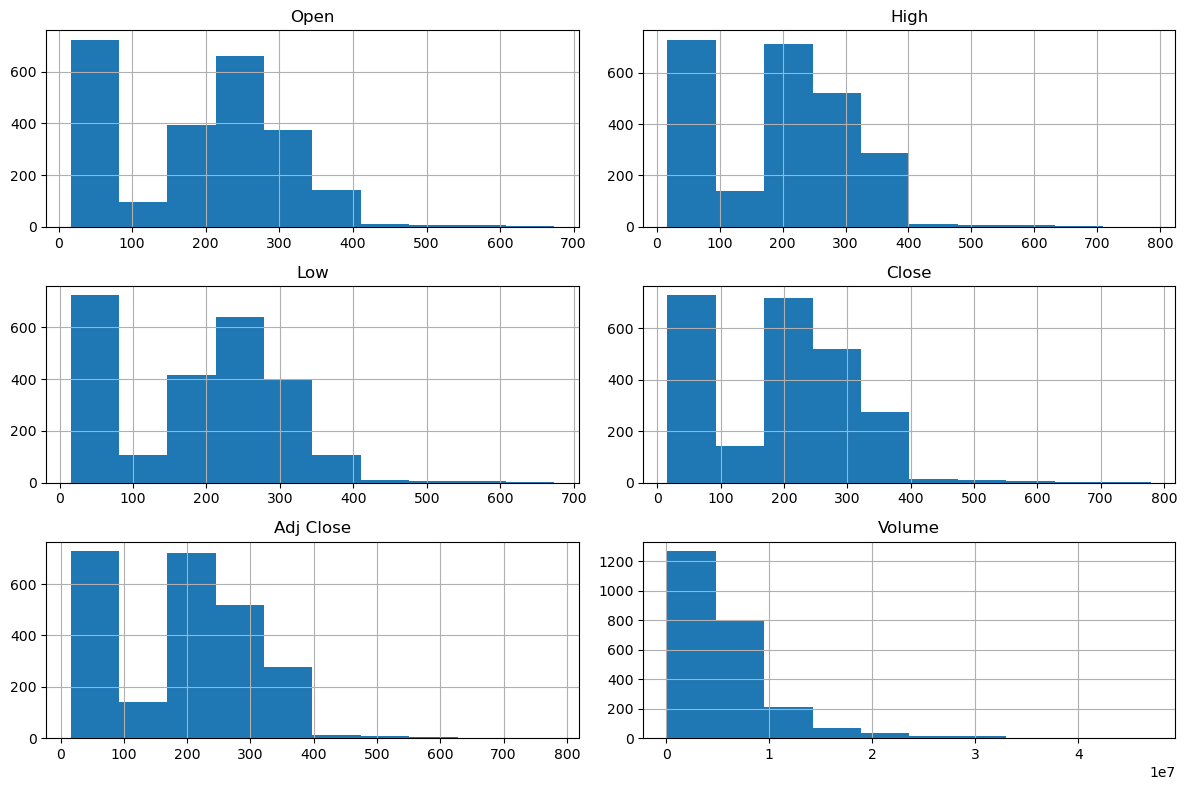

In [6]:
df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].hist(
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()


## 5.2 Univariate Analysis — Daily Return Distribution

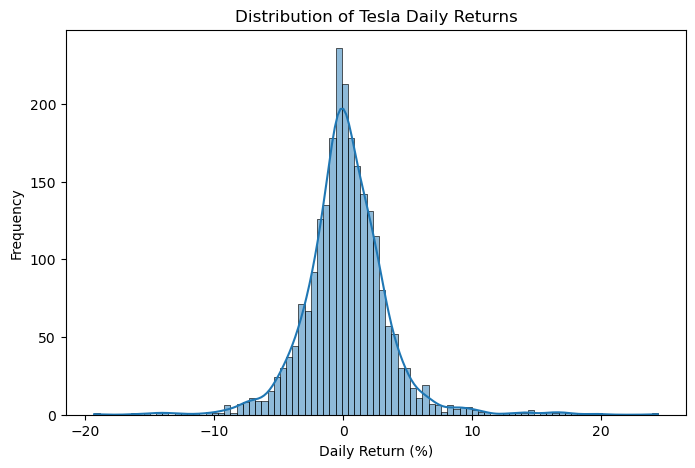

In [7]:
df["Daily_Return"] = df["Close"].pct_change() * 100

plt.figure(figsize=(8, 5))

sns.histplot(df["Daily_Return"].dropna(), kde=True)

plt.title("Distribution of Tesla Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

## 5.3 Univariate Analysis — Boxplot / Outlier Analysis

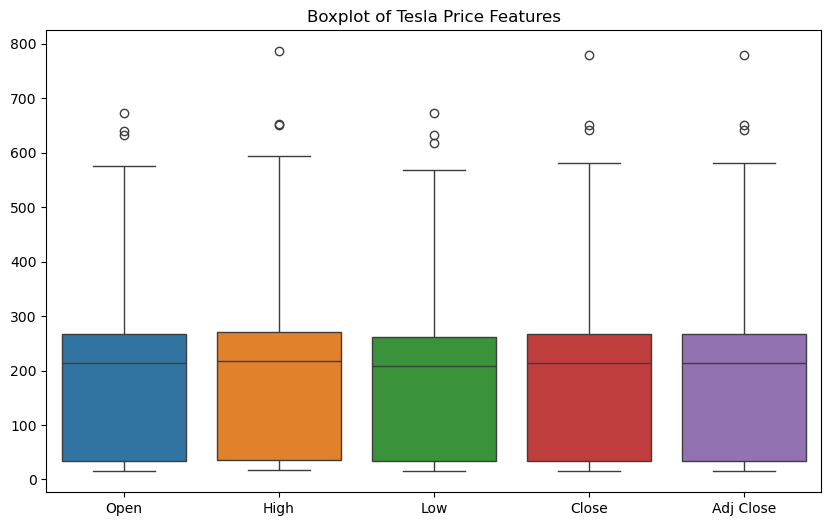

In [8]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[["Open", "High", "Low", "Close", "Adj Close"]]
)

plt.title("Boxplot of Tesla Price Features")

plt.show()

## 5.4 Bivariate Analysis — Date vs Closing Price

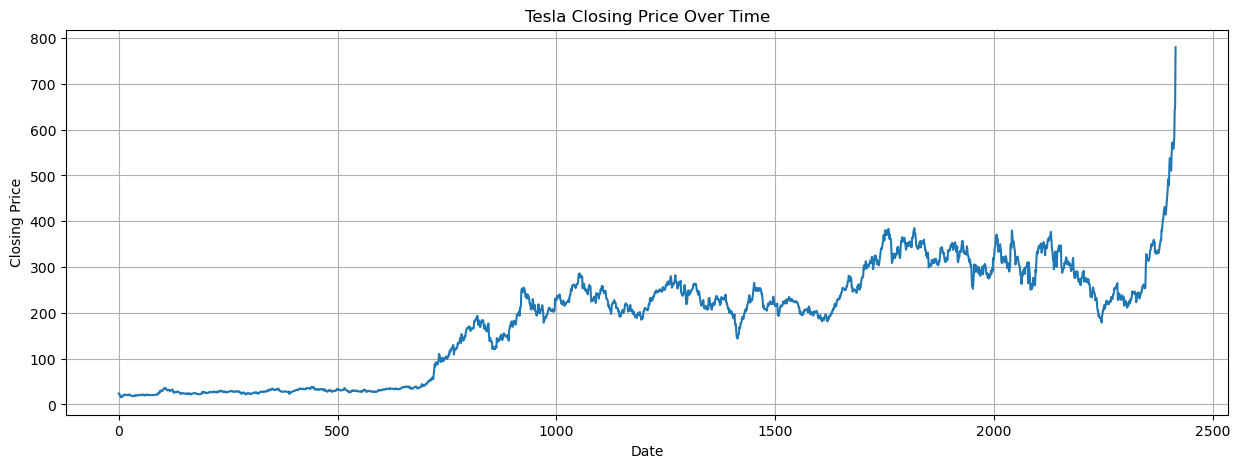

In [9]:
plt.figure(figsize=(15, 5))

plt.plot(df["Close"])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

## 5.5 Bivariate Analysis — Date vs Trading Volume

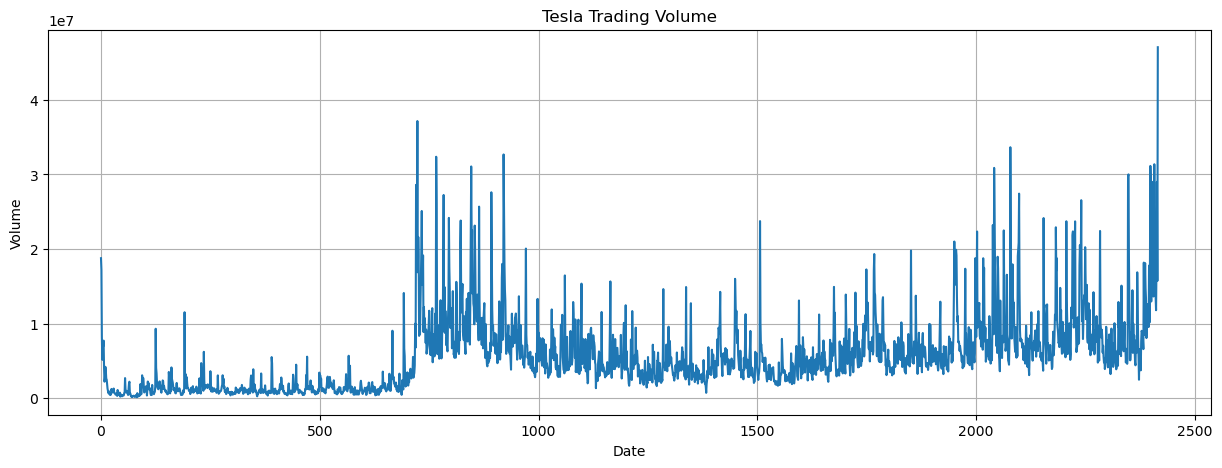

In [10]:
plt.figure(figsize=(15, 5))

plt.plot(df["Volume"])

plt.title("Tesla Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)

plt.show()

## 5.6 Multivariate Analysis — Correlation Heatmap

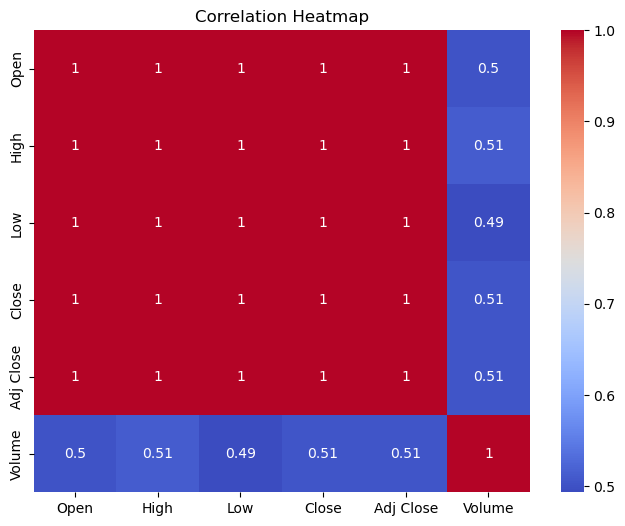

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 5.7 Time-Series Analysis — Moving Averages

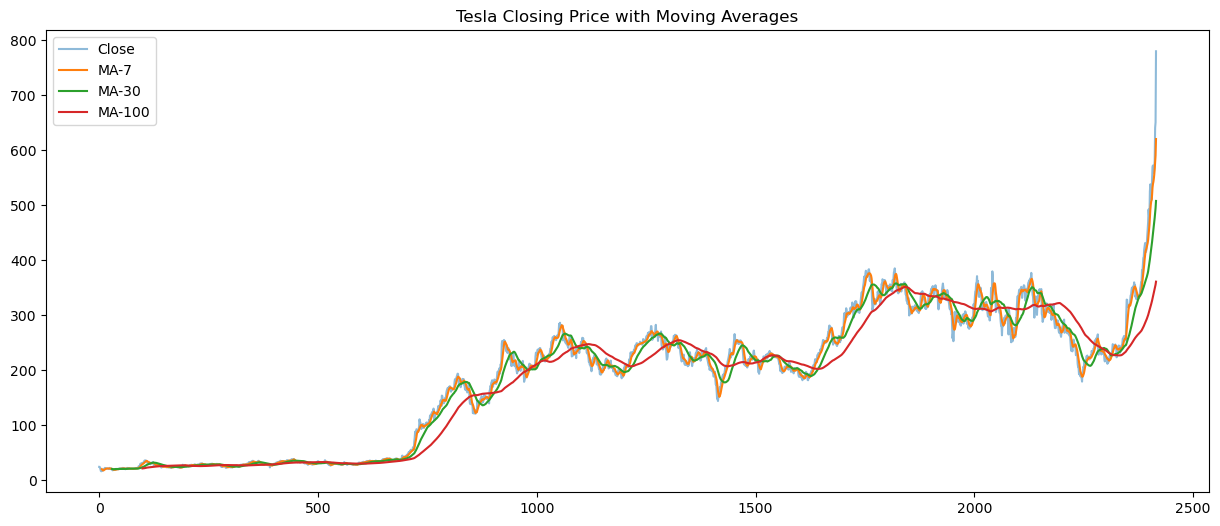

In [12]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()

plt.figure(figsize=(15, 6))

plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7")
plt.plot(df["MA30"], label="MA-30")
plt.plot(df["MA100"], label="MA-100")

plt.title("Tesla Closing Price with Moving Averages")
plt.legend()

plt.show()

## 5.8 Time-Series Analysis — Daily Returns and Volatility

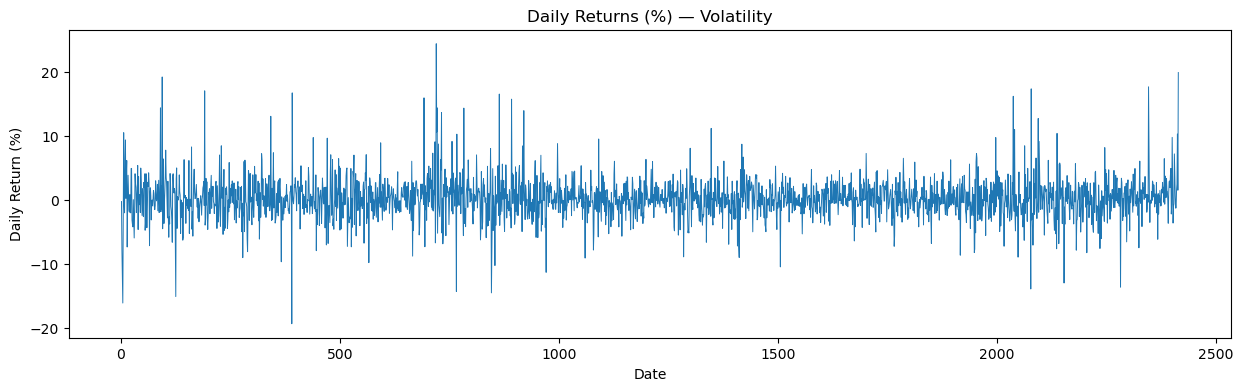

In [13]:
plt.figure(figsize=(15, 4))

plt.plot(df["Daily_Return"], linewidth=0.7)

plt.title("Daily Returns (%) — Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.show()

# Step 6: NLP Dataset Preparation

## 6.1 Install and Import NLP Library

In [14]:
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


In [15]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("NLP libraries imported successfully")

NLP libraries imported successfully


## 6.2 Create Tesla News Headlines Dataset

In [16]:
headlines = pd.DataFrame([
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),
    ("2013-08-05", "Tesla shares tumble after quarterly loss widens"),
    ("2014-02-20", "Tesla to build massive battery Gigafactory"),
    ("2014-10-01", "Tesla unveils Autopilot hardware for Model S"),
    ("2016-05-04", "Tesla posts wider-than-expected quarterly loss"),
    ("2016-08-01", "Tesla to acquire SolarCity in controversial deal"),
    ("2017-04-03", "Tesla passes Ford in market value amid delivery growth"),
    ("2018-04-05", "Tesla recalls thousands of Model X SUVs over steering flaw"),
    ("2018-08-07", "Musk says considering taking Tesla private, stock jumps"),
    ("2018-10-24", "Tesla posts record profit, shares surge on strong deliveries"),
    ("2019-01-30", "Tesla misses delivery targets, shares fall sharply"),
    ("2019-04-24", "Tesla reports steep quarterly loss, cash concerns weigh on stock"),
    ("2019-10-23", "Tesla surprises with profit, shares rally on strong China demand"),
    ("2020-01-29", "Tesla posts fifth straight profitable quarter, stock rallies"),
    ("2020-02-03", "Tesla shares surge to record high amid short squeeze")
], columns=["Date", "Headline"])

headlines["Date"] = pd.to_datetime(headlines["Date"])

print("NLP headlines dataset created successfully")
display(headlines)

NLP headlines dataset created successfully


,Date,Headline
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-10-01,Tesla unveils Autopilot hardware for Model S
4,2016-05-04,Tesla posts wider-than-expected quarterly loss
5,2016-08-01,Tesla to acquire SolarCity in controversial deal
6,2017-04-03,Tesla passes Ford in market value amid deliver...
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...
8,2018-08-07,"Musk says considering taking Tesla private, st..."
9,2018-10-24,"Tesla posts record profit, shares surge on str..."


## 6.3 NLP Dataset Understanding

In [17]:
print("First 5 records:")
display(headlines.head())

print("\nLast 5 records:")
display(headlines.tail())

print("\nDataset Shape:")
print(headlines.shape)

print("\nDataset Information:")
headlines.info()

print("\nMissing Values:")
print(headlines.isnull().sum())

print("\nDuplicate Rows:")
print(headlines.duplicated().sum())

First 5 records:


,Date,Headline
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-10-01,Tesla unveils Autopilot hardware for Model S
4,2016-05-04,Tesla posts wider-than-expected quarterly loss



Last 5 records:


,Date,Headline
10,2019-01-30,"Tesla misses delivery targets, shares fall sha..."
11,2019-04-24,"Tesla reports steep quarterly loss, cash conce..."
12,2019-10-23,"Tesla surprises with profit, shares rally on s..."
13,2020-01-29,"Tesla posts fifth straight profitable quarter,..."
14,2020-02-03,Tesla shares surge to record high amid short s...



Dataset Shape:
(15, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      15 non-null     datetime64[ns]
 1   Headline  15 non-null     object        
dtypes: datetime64[ns](1), object(1)
memory usage: 372.0+ bytes

Missing Values:
Date        0
Headline    0
dtype: int64

Duplicate Rows:
0


# Step 7: NLP Text Preprocessing

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

headlines["Clean_Headline"] = headlines["Headline"].apply(clean_text)

display(headlines[["Headline", "Clean_Headline"]])

,Headline,Clean_Headline
0,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...
1,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens
2,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory
3,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s
4,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss
5,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal
6,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...
7,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...
8,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...
9,"Tesla posts record profit, shares surge on str...",tesla posts record profit shares surge on stro...


# Step 8: NLP Sentiment Analysis

## 8.1 Generate Sentiment Scores

In [19]:
analyzer = SentimentIntensityAnalyzer()

headlines["Sentiment_Score"] = headlines["Clean_Headline"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

display(
    headlines[["Date", "Headline", "Clean_Headline", "Sentiment_Score"]]
)

,Date,Headline,Clean_Headline,Sentiment_Score
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...,0.7351
1,2013-08-05,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens,-0.0258
2,2014-02-20,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory,0.0000
3,2014-10-01,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s,0.0000
4,2016-05-04,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss,-0.3182
5,2016-08-01,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal,-0.2023
6,2017-04-03,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...,0.6124
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...,0.0000
8,2018-08-07,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...,0.0000
9,2018-10-24,"Tesla posts record profit, shares surge on str...",tesla posts record profit shares surge on stro...,0.8126


## 8.2 Positive / Neutral / Negative Classification

In [20]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

headlines["Sentiment_Label"] = headlines["Sentiment_Score"].apply(
    sentiment_label
)

display(
    headlines[
        ["Date", "Headline", "Sentiment_Score", "Sentiment_Label"]
    ]
)

,Date,Headline,Sentiment_Score,Sentiment_Label
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",0.7351,Positive
1,2013-08-05,Tesla shares tumble after quarterly loss widens,-0.0258,Neutral
2,2014-02-20,Tesla to build massive battery Gigafactory,0.0000,Neutral
3,2014-10-01,Tesla unveils Autopilot hardware for Model S,0.0000,Neutral
4,2016-05-04,Tesla posts wider-than-expected quarterly loss,-0.3182,Negative
5,2016-08-01,Tesla to acquire SolarCity in controversial deal,-0.2023,Negative
6,2017-04-03,Tesla passes Ford in market value amid deliver...,0.6124,Positive
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,0.0000,Neutral
8,2018-08-07,"Musk says considering taking Tesla private, st...",0.0000,Neutral
9,2018-10-24,"Tesla posts record profit, shares surge on str...",0.8126,Positive


## 8.3 Sentiment Summary

In [21]:
print("Sentiment Distribution:")
print(headlines["Sentiment_Label"].value_counts())

print("\nAverage Sentiment Score:")
print(headlines["Sentiment_Score"].mean())

Sentiment Distribution:
Sentiment_Label
Positive    7
Neutral     5
Negative    3
Name: count, dtype: int64

Average Sentiment Score:
0.20575333333333332


# Step 9: Date-wise NLP Aggregation

In [22]:
daily_sentiment = (
    headlines.groupby("Date")["Sentiment_Score"]
    .mean()
    .reset_index()
)

daily_sentiment.rename(
    columns={"Sentiment_Score": "Daily_Avg_Sentiment"},
    inplace=True
)

display(daily_sentiment)

,Date,Daily_Avg_Sentiment
0,2013-05-09,0.7351
1,2013-08-05,-0.0258
2,2014-02-20,0.0000
3,2014-10-01,0.0000
4,2016-05-04,-0.3182
5,2016-08-01,-0.2023
6,2017-04-03,0.6124
7,2018-04-05,0.0000
8,2018-08-07,0.0000
9,2018-10-24,0.8126


# Step 10: Merge Stock Data + NLP Data

In [23]:
# Merge stock data with daily NLP sentiment
df_nlp = df.merge(
    daily_sentiment,
    on="Date",
    how="left"
)

print("Stock and NLP data merged successfully")

display(df_nlp[[
    "Date",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Avg_Sentiment"
]].head())

Stock and NLP data merged successfully


,Date,Close,Adj Close,Volume,Daily_Avg_Sentiment
0,2010-06-29,23.889999,23.889999,18766300,NaN
1,2010-06-30,23.830000,23.830000,17187100,NaN
2,2010-07-01,21.959999,21.959999,8218800,NaN
3,2010-07-02,19.200001,19.200001,5139800,NaN
4,2010-07-06,16.110001,16.110001,6866900,NaN


# Step 11: Feature Engineering

## 11.1 Create / Verify Features

In [24]:
# Verify the engineered features

feature_columns = [
    "MA7",
    "MA30",
    "MA100",
    "Daily_Return"
]

print("Feature columns:")
print(feature_columns)

print("\nTarget column:")
print("Adj Close")

display(df[feature_columns + ["Adj Close"]].head())

Feature columns:
['MA7', 'MA30', 'MA100', 'Daily_Return']

Target column:
Adj Close


,MA7,MA30,MA100,Daily_Return,Adj Close
0,NaN,NaN,NaN,NaN,23.889999
1,NaN,NaN,NaN,-0.251147,23.830000
2,NaN,NaN,NaN,-7.847256,21.959999
3,NaN,NaN,NaN,-12.568297,19.200001
4,NaN,NaN,NaN,-16.093749,16.110001


## 11.2 Check Missing Values Created by Rolling Features

In [25]:
print("Missing values in engineered features:")

print(
    df[feature_columns + ["Adj Close"]].isnull().sum()
)

Missing values in engineered features:
MA7              6
MA30            29
MA100           99
Daily_Return     1
Adj Close        0
dtype: int64


## 11.3 Remove Rows with Insufficient History

In [26]:
df_model = df.dropna(
    subset=feature_columns + ["Adj Close"]
).copy()

print("Original shape:", df.shape)
print("Model-ready shape:", df_model.shape)

Original shape: (2416, 11)
Model-ready shape: (2317, 11)


# Step 12: Chronological Train-Test Split

The dataset is split chronologically into 80% training data and 20% testing data without shuffling.

In [27]:
# Chronological 80/20 train-test split

train_size = int(len(df_model) * 0.80)

train_data = df_model.iloc[:train_size].copy()
test_data = df_model.iloc[train_size:].copy()

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

print("\nTraining period:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTesting period:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Training data shape: (1853, 11)
Testing data shape: (464, 11)

Training period:
2010-11-17 00:00:00 to 2018-03-29 00:00:00

Testing period:
2018-04-02 00:00:00 to 2020-02-03 00:00:00


In [28]:
## Training

df_model.iloc[:train_size]

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA7,MA30,MA100
99,2010-11-17,30.200001,30.750000,28.610001,29.490000,29.490000,750000,-0.606673,28.832857,23.079667,20.987900
100,2010-11-18,30.670000,30.740000,28.920000,29.889999,29.889999,956100,1.356389,29.584286,23.395000,21.047900
101,2010-11-19,30.160000,31.370001,29.700001,30.990000,30.990000,1150500,3.680164,29.817143,23.747000,21.119500
102,2010-11-22,31.570000,33.450001,31.500000,33.400002,33.400002,1529700,7.776709,30.582857,24.185667,21.233900
103,2010-11-23,33.290001,35.680000,32.189999,34.570000,34.570000,1577800,3.502988,31.258571,24.663333,21.387600
...,...,...,...,...,...,...,...,...,...,...,...
1947,2018-03-23,311.250000,311.250000,300.450012,301.540009,301.540009,6654900,-2.445809,314.032859,329.594001,326.408601
1948,2018-03-26,307.339996,307.589996,291.359985,304.179993,304.179993,8375200,0.875500,310.972857,329.386001,326.249601
1949,2018-03-27,304.000000,304.269989,277.179993,279.179993,279.179993,13872000,-8.218818,304.948569,328.167667,325.726101
1950,2018-03-28,264.579987,268.679993,252.100006,257.779999,257.779999,21001400,-7.665304,296.979998,325.971666,325.093101


In [29]:
## Testing

df_model.iloc[train_size:]

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA7,MA30,MA100
1952,2018-04-02,256.260010,260.329987,244.589996,252.479996,252.479996,16114000,-5.129076,281.484286,321.379333,324.225701
1953,2018-04-03,269.820007,273.350006,254.490005,267.529999,267.529999,18844400,5.960869,275.545713,319.114000,323.873201
1954,2018-04-04,252.779999,288.369995,252.000000,286.940002,286.940002,19896700,7.255262,273.459998,317.519667,323.682101
1955,2018-04-05,289.339996,306.260010,288.200012,305.720001,305.720001,19121100,6.544922,273.679999,316.600334,323.695401
1956,2018-04-06,301.000000,309.279999,295.500000,299.299988,299.299988,13520300,-2.099965,276.554284,315.038000,323.658501
...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,1.591341,555.600010,469.665002,343.527601
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,2.485441,565.670009,477.085002,347.041701
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,10.296220,579.042864,485.728668,351.175301
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,1.523074,590.615723,494.781335,355.363101


## STEP 13 — Data Scaling

In [30]:
from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Return",
    "MA7",
    "MA30",
    "MA100"
]

scaler = MinMaxScaler()

# Fit only on training data
train_scaled = scaler.fit_transform(train_data[scale_columns])

# Transform test data using the same scaler
test_scaled = scaler.transform(test_data[scale_columns])

print("Training data scaled successfully")
print("Testing data scaled successfully")

print("\nScaled training shape:", train_scaled.shape)
print("Scaled testing shape:", test_scaled.shape)

Training data scaled successfully
Testing data scaled successfully

Scaled training shape: (1853, 10)
Scaled testing shape: (464, 10)


In [31]:
## Training 

train_scaled = scaler.fit_transform(train_data[scale_columns])

In [32]:
## Testing

test_scaled = scaler.transform(test_data[scale_columns])

# Step 14: Time-Series Sequence Creation

A 60-day lookback window is used to create sequential input data for 1-day, 5-day and 10-day ahead forecasting.

## 14.1 Create Sequence Function

In [33]:
def create_sequences(data, target_index, lookback=60, horizon=1):
    X = []
    y = []

    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i-lookback:i])
        y.append(data[i + horizon - 1, target_index])

    return np.array(X), np.array(y)

## 14.2 Find Adj Close Index

In [34]:
target_index = scale_columns.index("Adj Close")

print("Adj Close target index:", target_index)

Adj Close target index: 4


## 14.3 Create 1-Day Sequences

In [35]:
X_train_1, y_train_1 = create_sequences(
    train_scaled,
    target_index,
    lookback=60,
    horizon=1
)

X_test_1, y_test_1 = create_sequences(
    test_scaled,
    target_index,
    lookback=60,
    horizon=1
)

print("1-Day Prediction")
print("X_train:", X_train_1.shape)
print("y_train:", y_train_1.shape)
print("X_test:", X_test_1.shape)
print("y_test:", y_test_1.shape)

1-Day Prediction
X_train: (1793, 60, 10)
y_train: (1793,)
X_test: (404, 60, 10)
y_test: (404,)


## 14.4 Create 5-Day Sequences

In [36]:
X_train_5, y_train_5 = create_sequences(
    train_scaled,
    target_index,
    lookback=60,
    horizon=5
)

X_test_5, y_test_5 = create_sequences(
    test_scaled,
    target_index,
    lookback=60,
    horizon=5
)

print("5-Day Prediction")
print("X_train:", X_train_5.shape)
print("y_train:", y_train_5.shape)
print("X_test:", X_test_5.shape)
print("y_test:", y_test_5.shape)

5-Day Prediction
X_train: (1789, 60, 10)
y_train: (1789,)
X_test: (400, 60, 10)
y_test: (400,)


## 14.5 Create 10-Day Sequences

In [37]:
X_train_10, y_train_10 = create_sequences(
    train_scaled,
    target_index,
    lookback=60,
    horizon=10
)

X_test_10, y_test_10 = create_sequences(
    test_scaled,
    target_index,
    lookback=60,
    horizon=10
)

print("10-Day Prediction")
print("X_train:", X_train_10.shape)
print("y_train:", y_train_10.shape)
print("X_test:", X_test_10.shape)
print("y_test:", y_test_10.shape)

10-Day Prediction
X_train: (1784, 60, 10)
y_train: (1784,)
X_test: (395, 60, 10)
y_test: (395,)


# Step 15: SimpleRNN Architecture

## 15.1 Define SimpleRNN Model

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense

def build_simplernn(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        SimpleRNN(32),
        Dropout(0.2),

        Dense(1)
    ])

    return model

## 15.2 Build 1-Day SimpleRNN

In [39]:
input_shape = (X_train_1.shape[1], X_train_1.shape[2])

simple_rnn_1 = build_simplernn(input_shape)

simple_rnn_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 16: LSTM Architecture

## 16.1 Define LSTM Model

In [40]:
from tensorflow.keras.layers import LSTM

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        LSTM(32),
        Dropout(0.2),

        Dense(1)
    ])

    return model

## 16.2 Build 1-Day LSTM

In [41]:
input_shape = (X_train_1.shape[1], X_train_1.shape[2])

lstm_1 = build_lstm(input_shape)

lstm_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

# Step 17: Model Compilation

In [42]:
from tensorflow.keras.optimizers import Adam

# Compile SimpleRNN
simple_rnn_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Compile LSTM
lstm_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("SimpleRNN and LSTM models compiled successfully")

SimpleRNN and LSTM models compiled successfully


## 1. Adam

In [43]:
from tensorflow.keras.optimizers import Adam

## 2. Learning rate

In [44]:
learning_rate=0.001

## 3. Loss function

In [45]:
loss="mse"

## 4. Metric

In [46]:
metrics=["mae"]

## STEP 18 — Model Training

## 18.1 Import Training Callbacks

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## 18.2 Train SimpleRNN — 1 Day

In [48]:
early_stopping_rnn_1 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_rnn_1 = ModelCheckpoint(
    "best_simple_rnn_1day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_rnn_1 = simple_rnn_1.fit(
    X_train_1,
    y_train_1,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_rnn_1, checkpoint_rnn_1],
    shuffle=False,
    verbose=1
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.1757 - mae: 0.3336 - val_loss: 0.0227 - val_mae: 0.1301
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0766 - mae: 0.2192 - val_loss: 0.0046 - val_mae: 0.0560
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0510 - mae: 0.1797 - val_loss: 0.0083 - val_mae: 0.0765
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0307 - mae: 0.1361 - val_loss: 0.0213 - val_mae: 0.1315
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0257 - mae: 0.1278 - val_loss: 0.0152 - val_mae: 0.1046
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0189 - mae: 0.1075 - val_loss: 0.0056 - val_mae: 0.0635
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0171 - mae: 0.1033 - val_loss: 0.0036 - val_mae: 0.0494
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0135 - mae: 0.0894 - val_loss: 0.0070 - val_mae: 0.0715
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - lo

## 18.3 Train LSTM — 1 Day

In [49]:
early_stopping_lstm_1 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_lstm_1 = ModelCheckpoint(
    "best_lstm_1day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_lstm_1 = lstm_1.fit(
    X_train_1,
    y_train_1,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_lstm_1, checkpoint_lstm_1],
    shuffle=False,
    verbose=1
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0092 - mae: 0.0687 - val_loss: 0.0266 - val_mae: 0.1446
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0073 - mae: 0.0687 - val_loss: 0.0286 - val_mae: 0.1536
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0052 - mae: 0.0519 - val_loss: 0.0153 - val_mae: 0.1072
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0040 - mae: 0.0494 - val_loss: 0.0157 - val_mae: 0.1092
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0029 - mae: 0.0367 - val_loss: 0.0123 - val_mae: 0.0955
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0040 - mae: 0.0425 - val_loss: 0.0078 - val_mae: 0.0749
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0034 - mae: 0.0432 - val_loss: 0.0091 - val_mae: 0.0822
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0033 - mae: 0.0416 - val_loss: 0.0073 - val_mae: 0.0730
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - lo

## 18.4 Check Training History

In [50]:
print("SimpleRNN training completed.")
print("SimpleRNN epochs trained:", len(history_rnn_1.history["loss"]))

print("\nLSTM training completed.")
print("LSTM epochs trained:", len(history_lstm_1.history["loss"]))

SimpleRNN training completed.
SimpleRNN epochs trained: 17

LSTM training completed.
LSTM epochs trained: 32


## 18.5 Find Best Validation Loss

In [51]:
best_rnn_val_loss = min(history_rnn_1.history["val_loss"])
best_lstm_val_loss = min(history_lstm_1.history["val_loss"])

print("Best SimpleRNN validation loss:", best_rnn_val_loss)
print("Best LSTM validation loss:", best_lstm_val_loss)

Best SimpleRNN validation loss: 0.0036483684089034796
Best LSTM validation loss: 0.004011581186205149


## STEP 19 — Train All 6 Models

## 19.1 — SimpleRNN 5-Day Model

In [52]:
simple_rnn_5 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(60, 10)),
    Dropout(0.2),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(1)
])

simple_rnn_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("SimpleRNN 5-day model compiled successfully")

SimpleRNN 5-day model compiled successfully


In [53]:
## Train

early_stopping_rnn_5 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_rnn_5 = ModelCheckpoint(
    "best_simple_rnn_5day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_rnn_5 = simple_rnn_5.fit(
    X_train_5,
    y_train_5,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_rnn_5, checkpoint_rnn_5],
    shuffle=False,
    verbose=1
)

print("SimpleRNN 5-day training completed.")

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1485 - mae: 0.3031 - val_loss: 0.0939 - val_mae: 0.2883
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0698 - mae: 0.2098 - val_loss: 0.0116 - val_mae: 0.0880
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0467 - mae: 0.1700 - val_loss: 0.0432 - val_mae: 0.1927
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0299 - mae: 0.1353 - val_loss: 0.0088 - val_mae: 0.0771
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0239 - mae: 0.1214 - val_loss: 0.0112 - val_mae: 0.0879
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0206 - mae: 0.1117 - val_loss: 0.0103 - val_mae: 0.0847
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0184 - mae: 0.1068 - val_loss: 0.0074 - val_mae: 0.0708
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0142 - mae: 0.0932 - val_loss: 0.0075 - val_mae: 0.0712
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - lo

## 19.2 — SimpleRNN 10-Day Model

In [54]:
simple_rnn_10 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(60, 10)),
    Dropout(0.2),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(1)
])

simple_rnn_10.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("SimpleRNN 10-day model compiled successfully")

SimpleRNN 10-day model compiled successfully


In [55]:
## Train

early_stopping_rnn_10 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_rnn_10 = ModelCheckpoint(
    "best_simple_rnn_10day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_rnn_10 = simple_rnn_10.fit(
    X_train_10,
    y_train_10,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_rnn_10, checkpoint_rnn_10],
    shuffle=False,
    verbose=1
)

print("SimpleRNN 10-day training completed.")

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1424 - mae: 0.3043 - val_loss: 0.0151 - val_mae: 0.1053
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0645 - mae: 0.1992 - val_loss: 0.0186 - val_mae: 0.1209
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0432 - mae: 0.1615 - val_loss: 0.0186 - val_mae: 0.1191
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0405 - mae: 0.1572 - val_loss: 0.0264 - val_mae: 0.1443
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0210 - mae: 0.1125 - val_loss: 0.0125 - val_mae: 0.0955
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0186 - mae: 0.1045 - val_loss: 0.0126 - val_mae: 0.0964
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0150 - mae: 0.0951 - val_loss: 0.0158 - val_mae: 0.1088
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0128 - mae: 0.0871 - val_loss: 0.0131 - val_mae: 0.0983
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - lo

## 19.3 — LSTM 5-Day Model

In [56]:
lstm_5 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 10)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("LSTM 5-day model compiled successfully")

LSTM 5-day model compiled successfully


In [57]:
## Train

early_stopping_lstm_5 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_lstm_5 = ModelCheckpoint(
    "best_lstm_5day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_lstm_5 = lstm_5.fit(
    X_train_5,
    y_train_5,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_lstm_5, checkpoint_lstm_5],
    shuffle=False,
    verbose=1
)

print("LSTM 5-day training completed.")

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0090 - mae: 0.0689 - val_loss: 0.0495 - val_mae: 0.2026
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0097 - mae: 0.0801 - val_loss: 0.0383 - val_mae: 0.1767
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0069 - mae: 0.0644 - val_loss: 0.0164 - val_mae: 0.1115
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0048 - mae: 0.0508 - val_loss: 0.0197 - val_mae: 0.1231
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0050 - mae: 0.0497 - val_loss: 0.0272 - val_mae: 0.1481
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0039 - mae: 0.0432 - val_loss: 0.0214 - val_mae: 0.1301
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0036 - mae: 0.0415 - val_loss: 0.0166 - val_mae: 0.1126
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0034 - mae: 0.0391 - val_loss: 0.0158 - val_mae: 0.1095
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - lo

## 19.4 — LSTM 10-Day Model

In [58]:
lstm_10 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 10)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_10.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("LSTM 10-day model compiled successfully")

LSTM 10-day model compiled successfully


In [59]:
## Train

early_stopping_lstm_10 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_lstm_10 = ModelCheckpoint(
    "best_lstm_10day.keras",
    monitor="val_loss",
    save_best_only=True
)

history_lstm_10 = lstm_10.fit(
    X_train_10,
    y_train_10,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_lstm_10, checkpoint_lstm_10],
    shuffle=False,
    verbose=1
)

print("LSTM 10-day training completed.")

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0117 - mae: 0.0750 - val_loss: 0.0588 - val_mae: 0.2190
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0145 - mae: 0.0969 - val_loss: 0.0304 - val_mae: 0.1543
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0091 - mae: 0.0773 - val_loss: 0.0253 - val_mae: 0.1407
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0059 - mae: 0.0529 - val_loss: 0.0376 - val_mae: 0.1759
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0046 - mae: 0.0473 - val_loss: 0.0322 - val_mae: 0.1603
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0043 - mae: 0.0454 - val_loss: 0.0285 - val_mae: 0.1501
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0043 - mae: 0.0442 - val_loss: 0.0300 - val_mae: 0.1543
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0044 - mae: 0.0452 - val_loss: 0.0315 - val_mae: 0.1591
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - lo

## 19.5 — Final Training Summary

In [60]:
print("=" * 50)
print("STEP 19 - TRAINING SUMMARY")
print("=" * 50)

print("SimpleRNN 1-Day  :", len(history_rnn_1.history["loss"]), "epochs")
print("SimpleRNN 5-Day  :", len(history_rnn_5.history["loss"]), "epochs")
print("SimpleRNN 10-Day :", len(history_rnn_10.history["loss"]), "epochs")

print("LSTM 1-Day       :", len(history_lstm_1.history["loss"]), "epochs")
print("LSTM 5-Day       :", len(history_lstm_5.history["loss"]), "epochs")
print("LSTM 10-Day      :", len(history_lstm_10.history["loss"]), "epochs")

STEP 19 - TRAINING SUMMARY
SimpleRNN 1-Day  : 17 epochs
SimpleRNN 5-Day  : 17 epochs
SimpleRNN 10-Day : 15 epochs
LSTM 1-Day       : 32 epochs
LSTM 5-Day       : 28 epochs
LSTM 10-Day      : 13 epochs


## STEP 20 — Model Evaluation

## 20.1 Import Evaluation Metrics

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

## 20.2 Prediction Function

In [62]:
def evaluate_model(model, X_test, y_test, scaler, target_index=4):
    
    # Predict scaled values
    predictions_scaled = model.predict(X_test, verbose=0)
    
    # Create arrays for inverse transformation
    pred_full = np.zeros((len(predictions_scaled), 10))
    actual_full = np.zeros((len(y_test), 10))
    
    pred_full[:, target_index] = predictions_scaled.ravel()
    actual_full[:, target_index] = y_test.ravel()
    
    # Convert back to original price scale
    predictions = scaler.inverse_transform(pred_full)[:, target_index]
    actual = scaler.inverse_transform(actual_full)[:, target_index]
    
    # Metrics
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predictions)
    
    return predictions, actual, mse, rmse, mae

## 20.3 Evaluate SimpleRNN Models

In [63]:
# SimpleRNN - 1 Day
pred_rnn_1, actual_rnn_1, mse_rnn_1, rmse_rnn_1, mae_rnn_1 = evaluate_model(
    simple_rnn_1, X_test_1, y_test_1, scaler
)

# SimpleRNN - 5 Day
pred_rnn_5, actual_rnn_5, mse_rnn_5, rmse_rnn_5, mae_rnn_5 = evaluate_model(
    simple_rnn_5, X_test_5, y_test_5, scaler
)

# SimpleRNN - 10 Day
pred_rnn_10, actual_rnn_10, mse_rnn_10, rmse_rnn_10, mae_rnn_10 = evaluate_model(
    simple_rnn_10, X_test_10, y_test_10, scaler
)

print("SimpleRNN evaluation completed.")

SimpleRNN evaluation completed.


## 20.4 Evaluate LSTM Models

In [64]:
# LSTM - 1 Day
pred_lstm_1, actual_lstm_1, mse_lstm_1, rmse_lstm_1, mae_lstm_1 = evaluate_model(
    lstm_1, X_test_1, y_test_1, scaler
)

# LSTM - 5 Day
pred_lstm_5, actual_lstm_5, mse_lstm_5, rmse_lstm_5, mae_lstm_5 = evaluate_model(
    lstm_5, X_test_5, y_test_5, scaler
)

# LSTM - 10 Day
pred_lstm_10, actual_lstm_10, mse_lstm_10, rmse_lstm_10, mae_lstm_10 = evaluate_model(
    lstm_10, X_test_10, y_test_10, scaler
)

print("LSTM evaluation completed.")

LSTM evaluation completed.


## 20.5 Create Evaluation Table

In [65]:
results = pd.DataFrame({
    "Model": [
        "SimpleRNN", "SimpleRNN", "SimpleRNN",
        "LSTM", "LSTM", "LSTM"
    ],
    "Forecast_Horizon": [
        "1-Day", "5-Day", "10-Day",
        "1-Day", "5-Day", "10-Day"
    ],
    "MSE": [
        mse_rnn_1, mse_rnn_5, mse_rnn_10,
        mse_lstm_1, mse_lstm_5, mse_lstm_10
    ],
    "RMSE": [
        rmse_rnn_1, rmse_rnn_5, rmse_rnn_10,
        rmse_lstm_1, rmse_lstm_5, rmse_lstm_10
    ],
    "MAE": [
        mae_rnn_1, mae_rnn_5, mae_rnn_10,
        mae_lstm_1, mae_lstm_5, mae_lstm_10
    ]
})

results = results.sort_values(
    by=["Forecast_Horizon", "RMSE"]
).reset_index(drop=True)

print("===== MODEL EVALUATION RESULTS =====")
display(results)

===== MODEL EVALUATION RESULTS =====


,Model,Forecast_Horizon,MSE,RMSE,MAE
0,SimpleRNN,1-Day,1380.317825,37.152629,22.250907
1,LSTM,1-Day,1683.271707,41.027694,24.433418
2,SimpleRNN,10-Day,4258.966509,65.260758,40.803824
3,LSTM,10-Day,5727.729050,75.681762,50.378723
4,SimpleRNN,5-Day,2529.141392,50.290570,30.597877
5,LSTM,5-Day,3455.292084,58.781733,39.326356


# 20.6 RMSE Comparison Graph

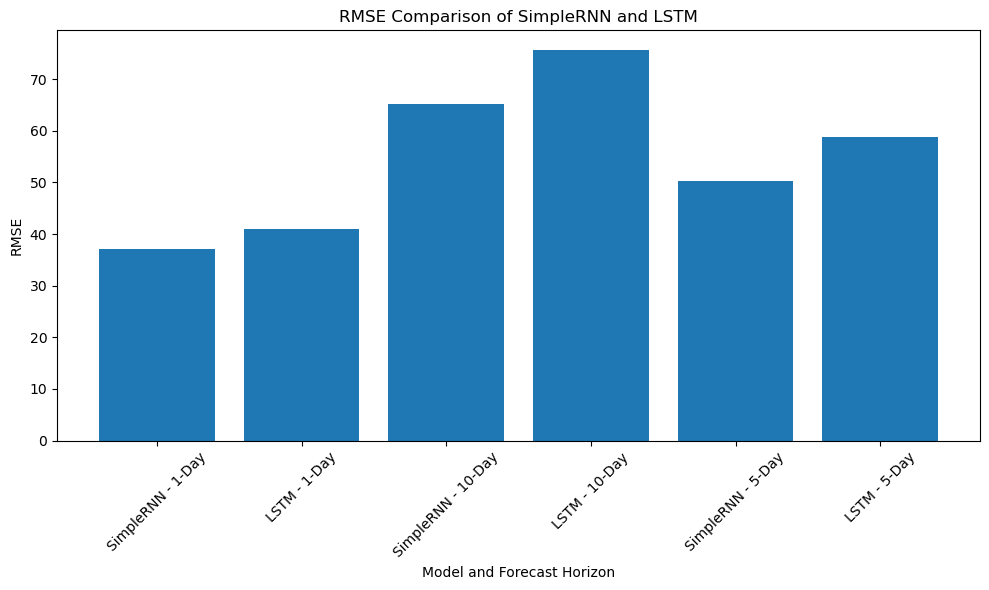

In [66]:

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"] + " - " + results["Forecast_Horizon"],
    results["RMSE"]
)

plt.title("RMSE Comparison of SimpleRNN and LSTM")
plt.xlabel("Model and Forecast Horizon")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# STEP 20.7 — MAE Comparison Graph

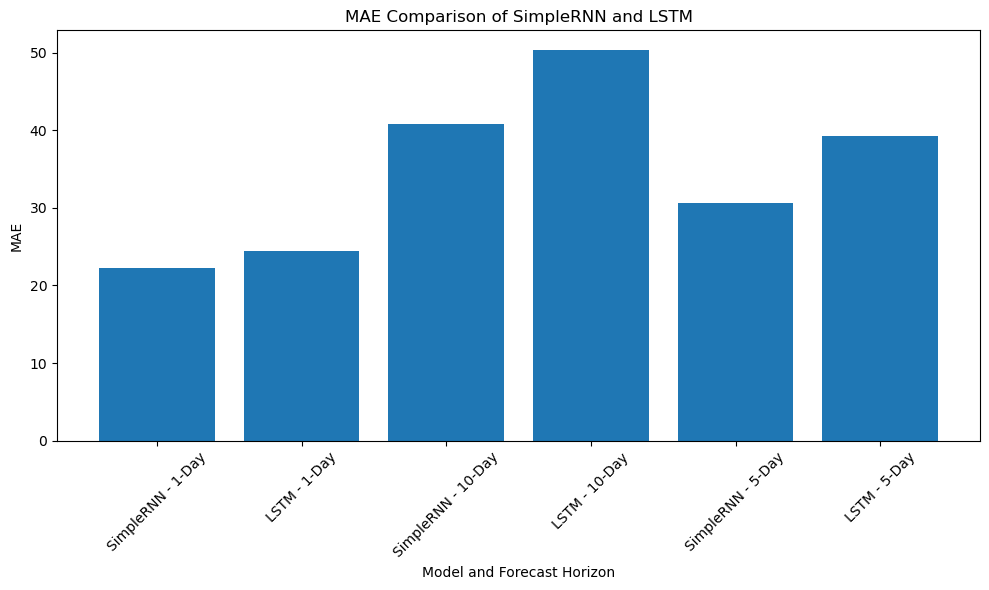

In [67]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"] + " - " + results["Forecast_Horizon"],
    results["MAE"]
)

plt.title("MAE Comparison of SimpleRNN and LSTM")
plt.xlabel("Model and Forecast Horizon")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 20.8 MSE Comparison Graph


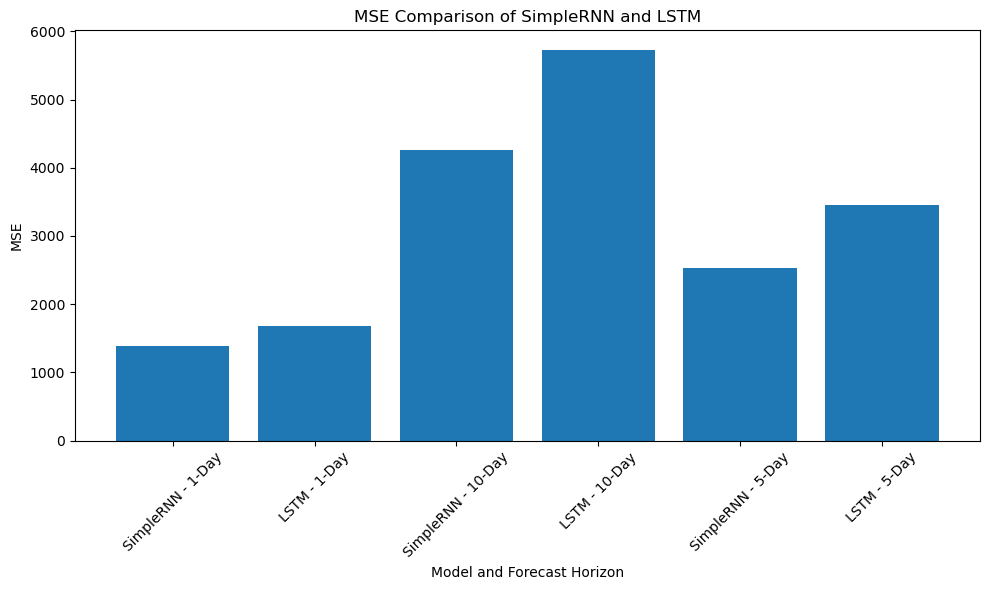

In [68]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"] + " - " + results["Forecast_Horizon"],
    results["MSE"]
)

plt.title("MSE Comparison of SimpleRNN and LSTM")
plt.xlabel("Model and Forecast Horizon")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## STEP 20.9 — Step 20 Summary

In [69]:
print("=" * 60)
print("STEP 20 - MODEL EVALUATION COMPLETED")
print("=" * 60)

print("\nMetrics calculated:")
print("1. MSE")
print("2. RMSE")
print("3. MAE")

print("\nEvaluation graphs generated:")
print("1. RMSE Comparison")
print("2. MAE Comparison")
print("3. MSE Comparison")

STEP 20 - MODEL EVALUATION COMPLETED

Metrics calculated:
1. MSE
2. RMSE
3. MAE

Evaluation graphs generated:
1. RMSE Comparison
2. MAE Comparison
3. MSE Comparison


## STEP 21 — Actual vs Predicted Stock Price Visualization

## 21.1 — Generate Predictions

In [70]:
# SimpleRNN predictions
pred_rnn_1 = simple_rnn_1.predict(X_test_1, verbose=0)
pred_rnn_5 = simple_rnn_5.predict(X_test_5, verbose=0)
pred_rnn_10 = simple_rnn_10.predict(X_test_10, verbose=0)

# LSTM predictions
pred_lstm_1 = lstm_1.predict(X_test_1, verbose=0)
pred_lstm_5 = lstm_5.predict(X_test_5, verbose=0)
pred_lstm_10 = lstm_10.predict(X_test_10, verbose=0)

print("Predictions generated successfully")

print("\nPrediction Shapes:")
print("SimpleRNN 1-Day :", pred_rnn_1.shape)
print("LSTM 1-Day     :", pred_lstm_1.shape)
print("SimpleRNN 5-Day :", pred_rnn_5.shape)
print("LSTM 5-Day     :", pred_lstm_5.shape)
print("SimpleRNN 10-Day:", pred_rnn_10.shape)
print("LSTM 10-Day     :", pred_lstm_10.shape)

Predictions generated successfully

Prediction Shapes:
SimpleRNN 1-Day : (404, 1)
LSTM 1-Day     : (404, 1)
SimpleRNN 5-Day : (400, 1)
LSTM 5-Day     : (400, 1)
SimpleRNN 10-Day: (395, 1)
LSTM 10-Day     : (395, 1)


# STEP 21.2 - Convert Predictions Back to Original Scale

In [71]:

target_index = 4
n_features = 10

def inverse_transform_target(predictions, scaler, n_features, target_index):
    temp = np.zeros((len(predictions), n_features))
    temp[:, target_index] = predictions.reshape(-1)
    return scaler.inverse_transform(temp)[:, target_index]


# 1-Day
actual_1 = inverse_transform_target(
    y_test_1, scaler, n_features, target_index
)

pred_rnn_1_actual = inverse_transform_target(
    pred_rnn_1, scaler, n_features, target_index
)

pred_lstm_1_actual = inverse_transform_target(
    pred_lstm_1, scaler, n_features, target_index
)


# 5-Day
actual_5 = inverse_transform_target(
    y_test_5, scaler, n_features, target_index
)

pred_rnn_5_actual = inverse_transform_target(
    pred_rnn_5, scaler, n_features, target_index
)

pred_lstm_5_actual = inverse_transform_target(
    pred_lstm_5, scaler, n_features, target_index
)


# 10-Day
actual_10 = inverse_transform_target(
    y_test_10, scaler, n_features, target_index
)

pred_rnn_10_actual = inverse_transform_target(
    pred_rnn_10, scaler, n_features, target_index
)

pred_lstm_10_actual = inverse_transform_target(
    pred_lstm_10, scaler, n_features, target_index
)

print("Predictions converted back to original price scale successfully.")

print("\nOriginal-scale shapes:")
print("1-Day :", actual_1.shape, pred_rnn_1_actual.shape, pred_lstm_1_actual.shape)
print("5-Day :", actual_5.shape, pred_rnn_5_actual.shape, pred_lstm_5_actual.shape)
print("10-Day:", actual_10.shape, pred_rnn_10_actual.shape, pred_lstm_10_actual.shape)

Predictions converted back to original price scale successfully.

Original-scale shapes:
1-Day : (404,) (404,) (404,)
5-Day : (400,) (400,) (400,)
10-Day: (395,) (395,) (395,)


# STEP 21.3 - Actual vs Predicted Graphs

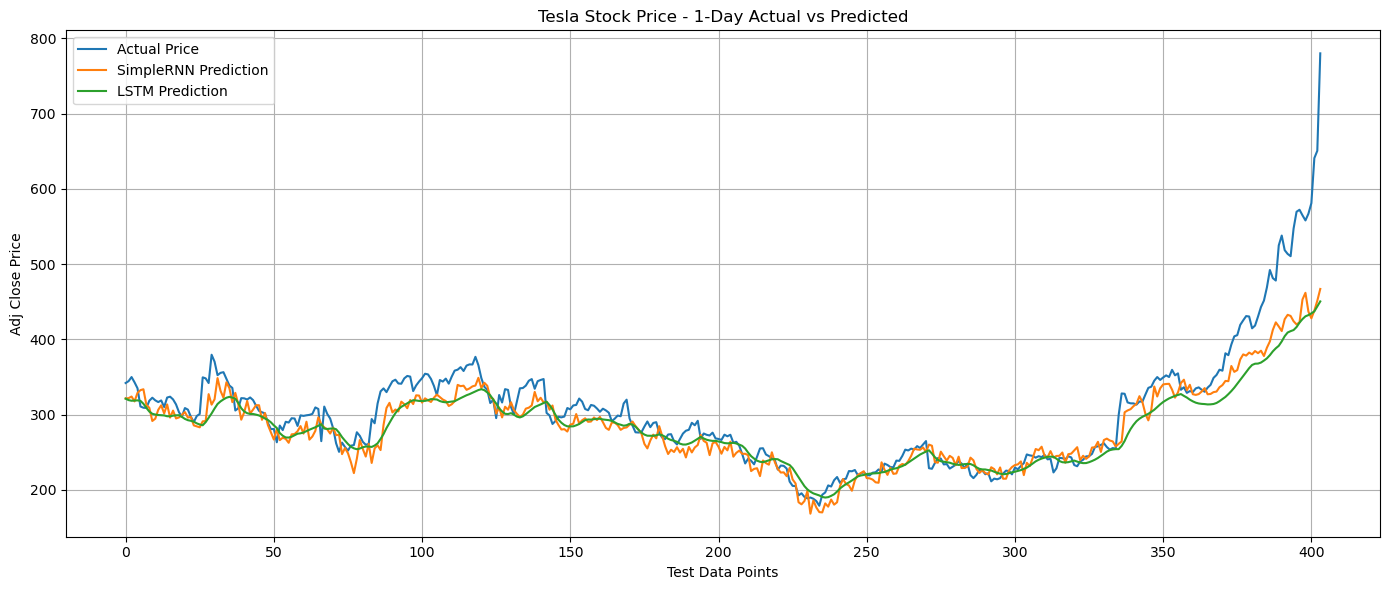

In [72]:
# ============================================================
# STEP 21.3 - Actual vs Predicted Graphs
# ============================================================

# 1-Day Forecast
plt.figure(figsize=(14, 6))

plt.plot(actual_1, label="Actual Price")
plt.plot(pred_rnn_1_actual, label="SimpleRNN Prediction")
plt.plot(pred_lstm_1_actual, label="LSTM Prediction")

plt.title("Tesla Stock Price - 1-Day Actual vs Predicted")
plt.xlabel("Test Data Points")
plt.ylabel("Adj Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 21.4 → 5-Day Actual vs Predicted

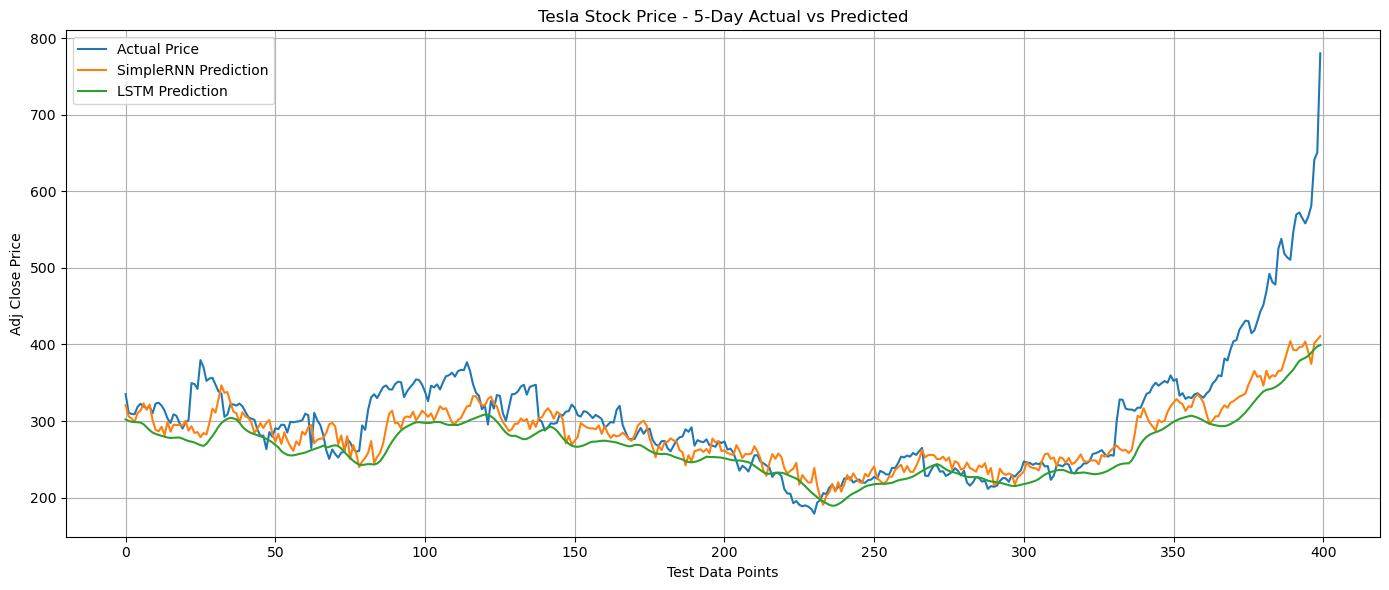

In [73]:
plt.figure(figsize=(14, 6))

plt.plot(actual_5, label="Actual Price")
plt.plot(pred_rnn_5_actual, label="SimpleRNN Prediction")
plt.plot(pred_lstm_5_actual, label="LSTM Prediction")

plt.title("Tesla Stock Price - 5-Day Actual vs Predicted")
plt.xlabel("Test Data Points")
plt.ylabel("Adj Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 21.5 → 10-Day Actual vs Predicted

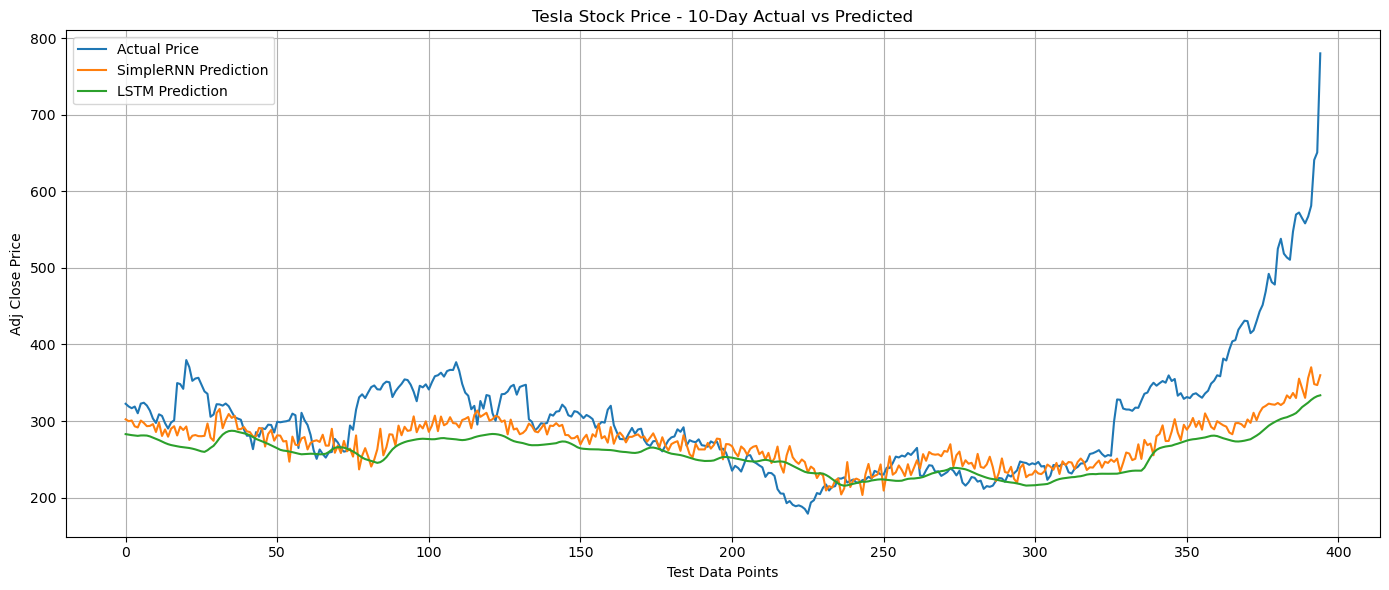

In [74]:
plt.figure(figsize=(14, 6))

plt.plot(actual_10, label="Actual Price")
plt.plot(pred_rnn_10_actual, label="SimpleRNN Prediction")
plt.plot(pred_lstm_10_actual, label="LSTM Prediction")

plt.title("Tesla Stock Price - 10-Day Actual vs Predicted")
plt.xlabel("Test Data Points")
plt.ylabel("Adj Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 21.6 - Combined Actual vs Predicted Comparison

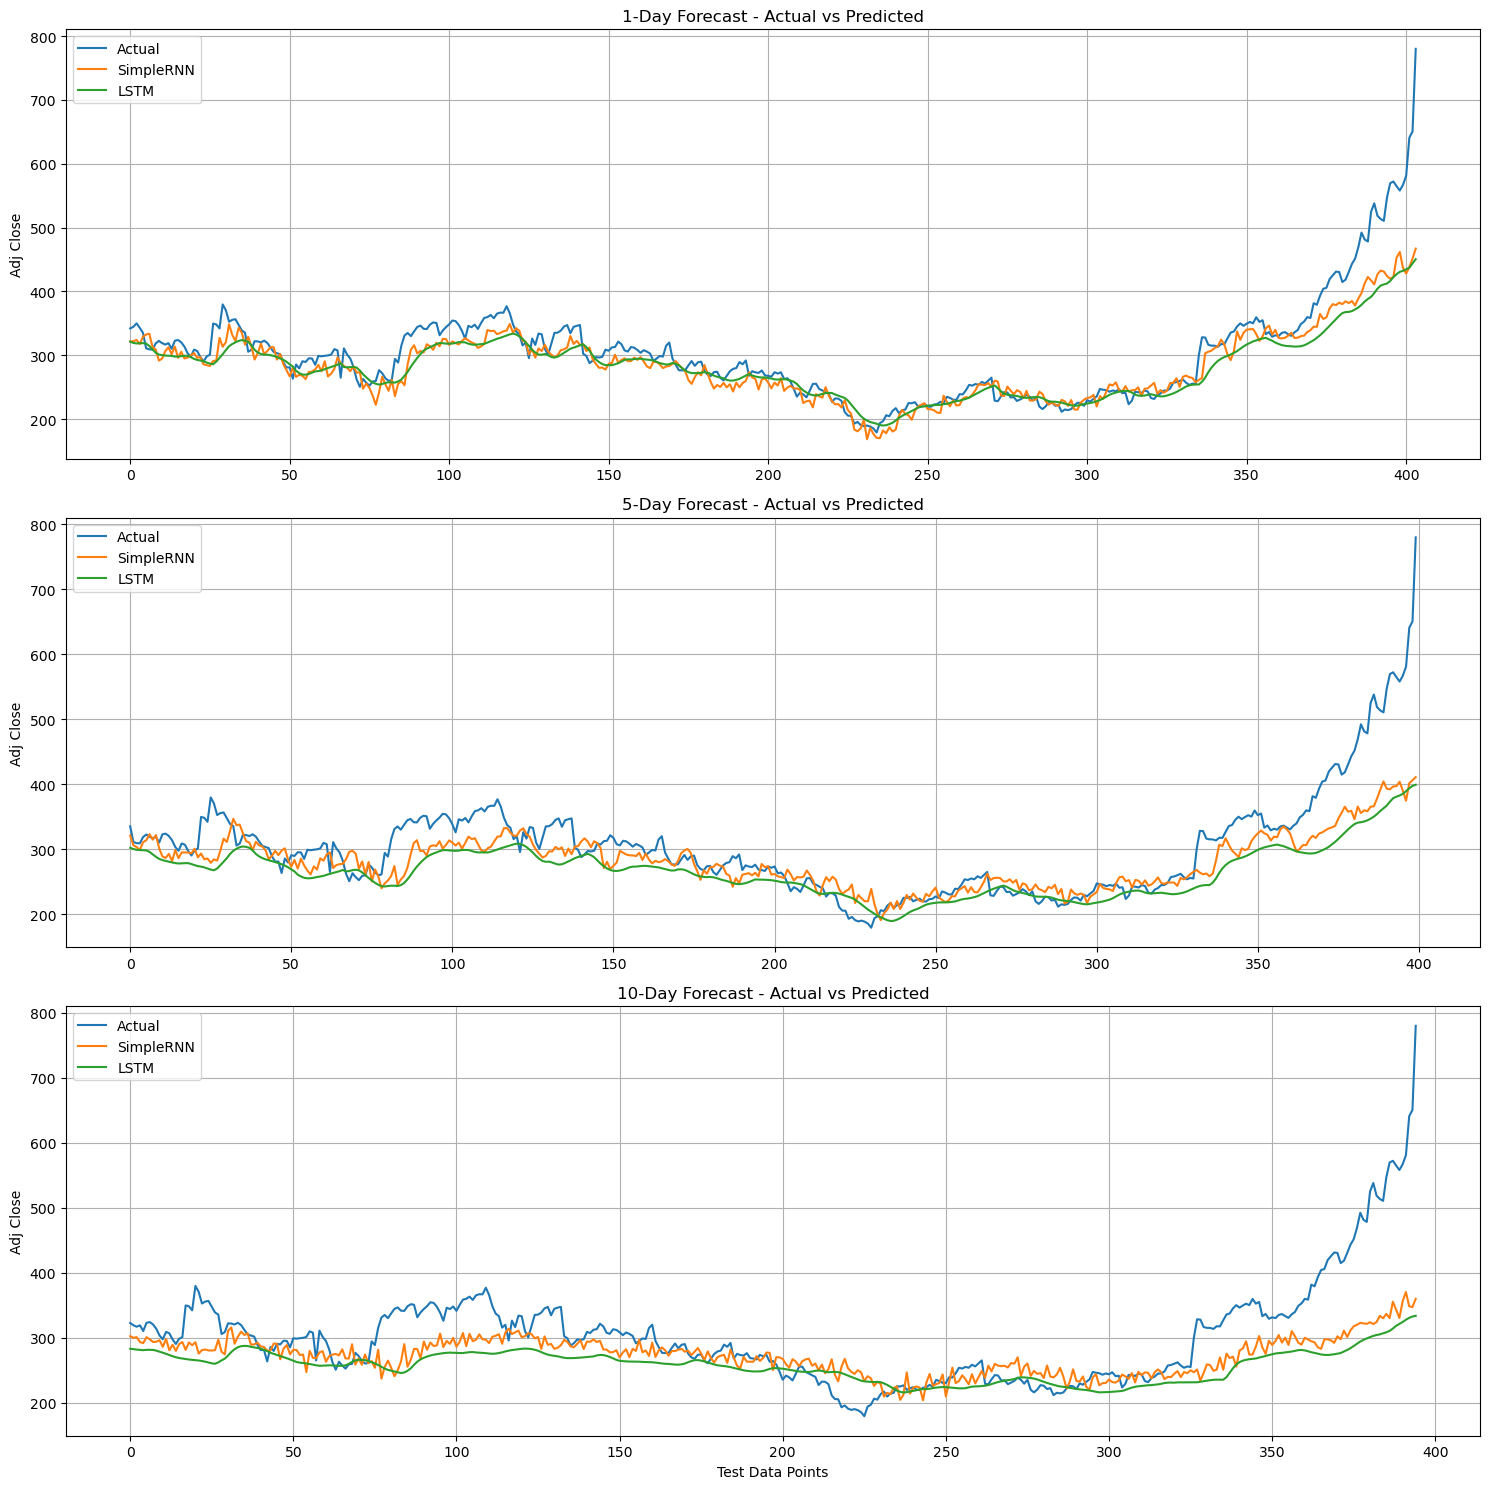

In [75]:

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# 1-Day
axes[0].plot(actual_1, label="Actual")
axes[0].plot(pred_rnn_1_actual, label="SimpleRNN")
axes[0].plot(pred_lstm_1_actual, label="LSTM")
axes[0].set_title("1-Day Forecast - Actual vs Predicted")
axes[0].set_ylabel("Adj Close")
axes[0].legend()
axes[0].grid(True)

# 5-Day
axes[1].plot(actual_5, label="Actual")
axes[1].plot(pred_rnn_5_actual, label="SimpleRNN")
axes[1].plot(pred_lstm_5_actual, label="LSTM")
axes[1].set_title("5-Day Forecast - Actual vs Predicted")
axes[1].set_ylabel("Adj Close")
axes[1].legend()
axes[1].grid(True)

# 10-Day
axes[2].plot(actual_10, label="Actual")
axes[2].plot(pred_rnn_10_actual, label="SimpleRNN")
axes[2].plot(pred_lstm_10_actual, label="LSTM")
axes[2].set_title("10-Day Forecast - Actual vs Predicted")
axes[2].set_xlabel("Test Data Points")
axes[2].set_ylabel("Adj Close")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## STEP 22 — Model Comparison + Graphs

# STEP 22.1 - Model Comparison 

In [76]:

comparison_data = {
    "Forecast_Horizon": [
        "1-Day", "1-Day",
        "5-Day", "5-Day",
        "10-Day", "10-Day"
    ],
    "Model": [
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM"
    ],
    "MSE": [
        781.901647,
        1018.301113,
        1807.752821,
        3244.411290,
        1928.788097,
        5470.999589
    ],
    "RMSE": [
        27.962504,
        31.910831,
        42.517677,
        56.959734,
        43.917970,
        73.966206
    ],
    "MAE": [
        15.937511,
        18.618962,
        26.041495,
        40.119302,
        29.882159,
        48.661746
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("===== MODEL COMPARISON =====")
display(comparison_df)

===== MODEL COMPARISON =====


,Forecast_Horizon,Model,MSE,RMSE,MAE
0,1-Day,SimpleRNN,781.901647,27.962504,15.937511
1,1-Day,LSTM,1018.301113,31.910831,18.618962
2,5-Day,SimpleRNN,1807.752821,42.517677,26.041495
3,5-Day,LSTM,3244.411290,56.959734,40.119302
4,10-Day,SimpleRNN,1928.788097,43.917970,29.882159
5,10-Day,LSTM,5470.999589,73.966206,48.661746


## 22.2 Best Model for Each Horizon

In [77]:
# ============================================================
# STEP 22.2 - BEST MODEL SELECTION
# ============================================================

best_models = []

for horizon in ["1-Day", "5-Day", "10-Day"]:
    subset = comparison_df[
        comparison_df["Forecast_Horizon"] == horizon
    ]
    
    best_row = subset.loc[subset["RMSE"].idxmin()]
    
    best_models.append({
        "Forecast_Horizon": horizon,
        "Best_Model": best_row["Model"],
        "MSE": best_row["MSE"],
        "RMSE": best_row["RMSE"],
        "MAE": best_row["MAE"]
    })

best_model_df = pd.DataFrame(best_models)

print("===== BEST MODEL BY FORECAST HORIZON =====")
display(best_model_df)

===== BEST MODEL BY FORECAST HORIZON =====


,Forecast_Horizon,Best_Model,MSE,RMSE,MAE
0,1-Day,SimpleRNN,781.901647,27.962504,15.937511
1,5-Day,SimpleRNN,1807.752821,42.517677,26.041495
2,10-Day,SimpleRNN,1928.788097,43.917970,29.882159


## 22.3 RMSE Comparison Graph

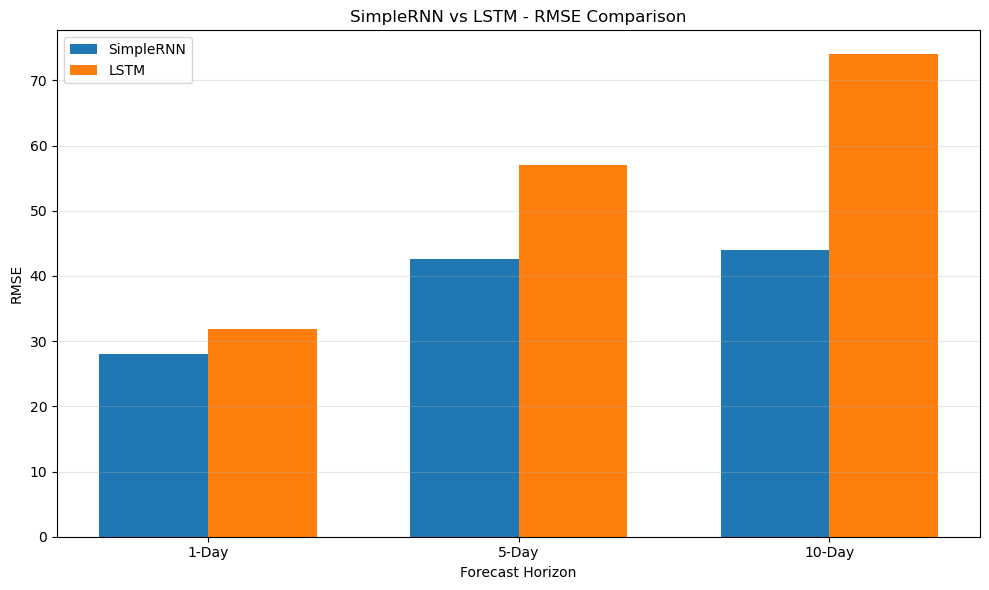

In [78]:
import matplotlib.pyplot as plt
import numpy as np

horizons = ["1-Day", "5-Day", "10-Day"]

rnn_rmse = [27.962504, 42.517677, 43.917970]
lstm_rmse = [31.910831, 56.959734, 73.966206]

x = np.arange(len(horizons))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, rnn_rmse, width, label="SimpleRNN")
plt.bar(x + width/2, lstm_rmse, width, label="LSTM")

plt.xticks(x, horizons)
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.title("SimpleRNN vs LSTM - RMSE Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 22.4 MAE Comparison Graph

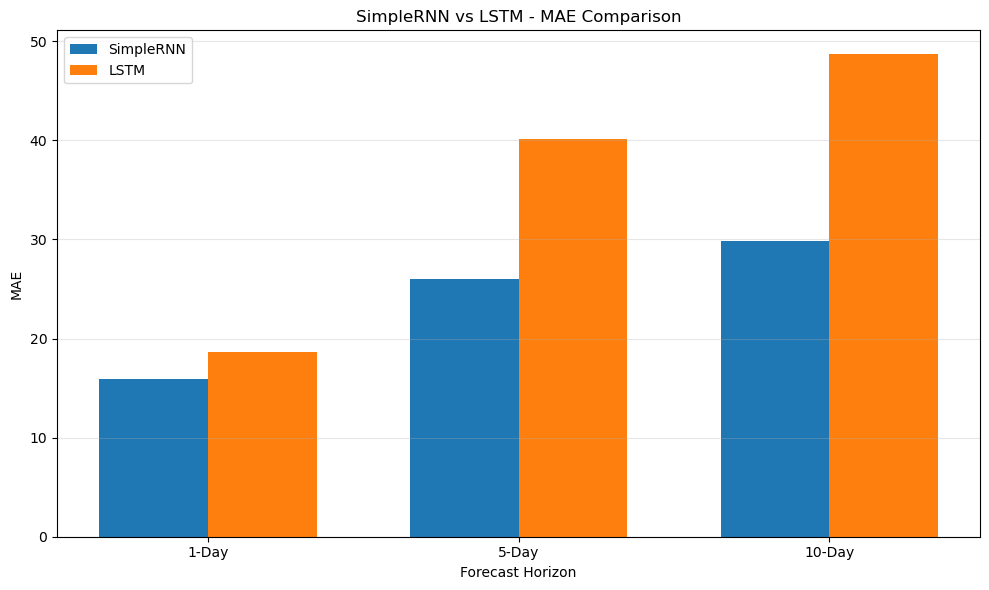

In [79]:
rnn_mae = [15.937511, 26.041495, 29.882159]
lstm_mae = [18.618962, 40.119302, 48.661746]

x = np.arange(len(horizons))

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, rnn_mae, width, label="SimpleRNN")
plt.bar(x + width/2, lstm_mae, width, label="LSTM")

plt.xticks(x, horizons)
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")
plt.title("SimpleRNN vs LSTM - MAE Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 22.5 MSE Comparison Graph

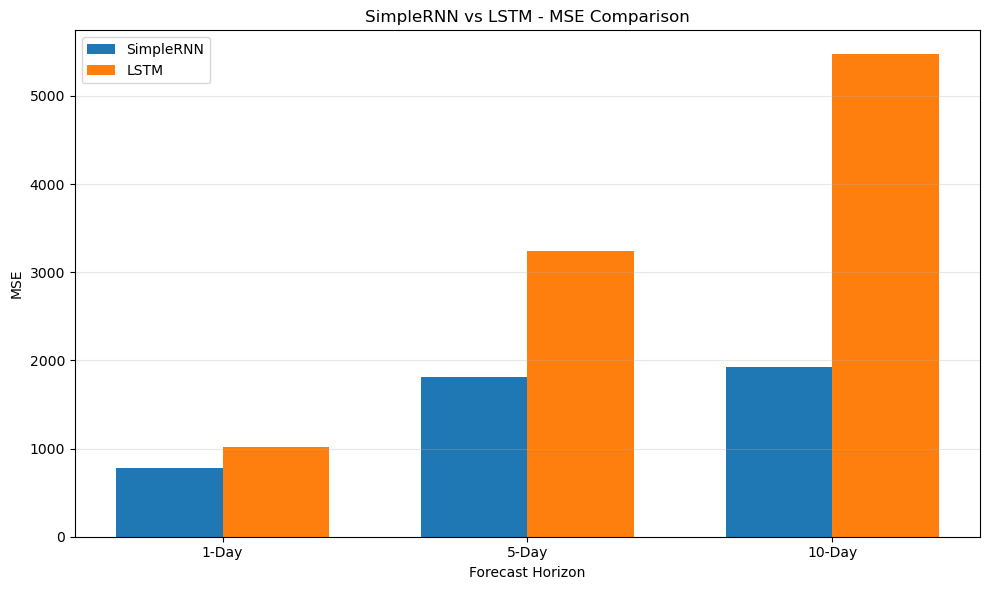

In [80]:
rnn_mse = [781.901647, 1807.752821, 1928.788097]
lstm_mse = [1018.301113, 3244.411290, 5470.999589]

x = np.arange(len(horizons))

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, rnn_mse, width, label="SimpleRNN")
plt.bar(x + width/2, lstm_mse, width, label="LSTM")

plt.xticks(x, horizons)
plt.xlabel("Forecast Horizon")
plt.ylabel("MSE")
plt.title("SimpleRNN vs LSTM - MSE Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 22.6 Overall Model Comparison Graph

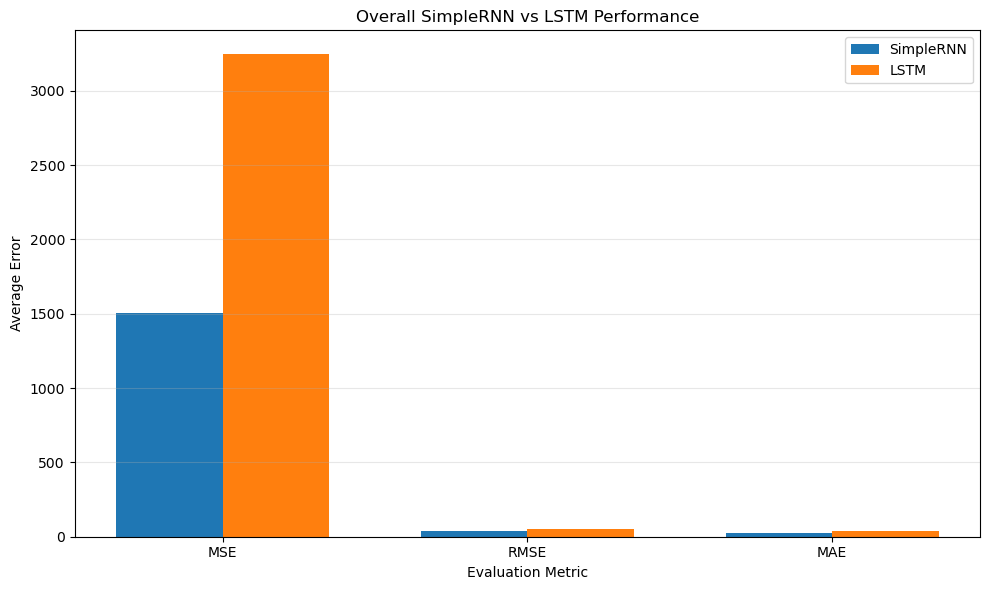

In [81]:
metrics = ["MSE", "RMSE", "MAE"]

rnn_values = [
    comparison_df[comparison_df["Model"] == "SimpleRNN"]["MSE"].mean(),
    comparison_df[comparison_df["Model"] == "SimpleRNN"]["RMSE"].mean(),
    comparison_df[comparison_df["Model"] == "SimpleRNN"]["MAE"].mean()
]

lstm_values = [
    comparison_df[comparison_df["Model"] == "LSTM"]["MSE"].mean(),
    comparison_df[comparison_df["Model"] == "LSTM"]["RMSE"].mean(),
    comparison_df[comparison_df["Model"] == "LSTM"]["MAE"].mean()
]

x = np.arange(len(metrics))

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, rnn_values, width, label="SimpleRNN")
plt.bar(x + width/2, lstm_values, width, label="LSTM")

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metric")
plt.ylabel("Average Error")
plt.title("Overall SimpleRNN vs LSTM Performance")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 22.7 Final Step 22 Output

In [82]:

print("=" * 60)
print("STEP 22 - MODEL COMPARISON COMPLETED")
print("=" * 60)

print("\nBest Models:")

for _, row in best_model_df.iterrows():
    print(
        f"{row['Forecast_Horizon']} : "
        f"{row['Best_Model']} "
        f"(RMSE = {row['RMSE']:.4f}, MAE = {row['MAE']:.4f})"
    )

print("\nOverall Result:")
print("SimpleRNN achieved lower MSE, RMSE and MAE")
print("for 1-Day, 5-Day and 10-Day forecasting.")

STEP 22 - MODEL COMPARISON COMPLETED

Best Models:
1-Day : SimpleRNN (RMSE = 27.9625, MAE = 15.9375)
5-Day : SimpleRNN (RMSE = 42.5177, MAE = 26.0415)
10-Day : SimpleRNN (RMSE = 43.9180, MAE = 29.8822)

Overall Result:
SimpleRNN achieved lower MSE, RMSE and MAE
for 1-Day, 5-Day and 10-Day forecasting.


# STEP 23.1 - GridSearchCV Imports

In [83]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

print("GridSearchCV and Keras wrapper imported successfully.")

GridSearchCV and Keras wrapper imported successfully.


# STEP 23.2 - Build LSTM Model for GridSearchCV

In [84]:
def build_lstm_grid(units=32, dropout_rate=0.2, learning_rate=0.001):

    model = Sequential([
        LSTM(
            units,
            return_sequences=True,
            input_shape=(60, 10)
        ),
        Dropout(dropout_rate),

        LSTM(units // 2),
        Dropout(dropout_rate),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


print("GridSearch LSTM model function created successfully.")

GridSearch LSTM model function created successfully.


# STEP 23.3 - KerasRegressor Wrapper

In [85]:
grid_model = KerasRegressor(
    model=build_lstm_grid,
    epochs=20,
    batch_size=32,
    verbose=0
)

print("KerasRegressor created successfully.")

KerasRegressor created successfully.


In [86]:
# STEP 23.4 - Define Hyperparameter Grid

In [87]:
param_grid = {
    "model__units": [32, 64],
    "model__dropout_rate": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.0005]
}

print("Hyperparameter grid defined successfully.")

print("\nLSTM Units      :", param_grid["model__units"])
print("Dropout Rates   :", param_grid["model__dropout_rate"])
print("Learning Rates  :", param_grid["model__learning_rate"])

print("\nTotal combinations:",
      len(param_grid["model__units"])
      * len(param_grid["model__dropout_rate"])
      * len(param_grid["model__learning_rate"]))

Hyperparameter grid defined successfully.

LSTM Units      : [32, 64]
Dropout Rates   : [0.2, 0.3]
Learning Rates  : [0.001, 0.0005]

Total combinations: 8


# STEP 23.5 - Run GridSearchCV

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=1
)

print("Starting GridSearchCV...")
print("Total parameter combinations:", 8)
print("Cross-validation folds:", 3)
print("Total model fits:", 24)

grid_search.fit(
    X_train_1,
    y_train_1
)

print("\nGridSearchCV completed successfully.")

In [88]:
quick_model = KerasRegressor(
    model=build_lstm_grid,
    epochs=3,
    batch_size=32,
    verbose=0
)

quick_param_grid = {
    "model__units": [32, 64],
    "model__dropout_rate": [0.2],
    "model__learning_rate": [0.001]
}

quick_grid = GridSearchCV(
    estimator=quick_model,
    param_grid=quick_param_grid,
    scoring="neg_mean_squared_error",
    cv=2,
    verbose=1,
    n_jobs=1
)

print("Starting Quick GridSearchCV...")
print("Parameter combinations: 2")
print("CV folds: 2")
print("Total fits: 4")

quick_grid.fit(X_train_1, y_train_1)

print("\nQuick GridSearchCV completed successfully.")

Starting Quick GridSearchCV...
Parameter combinations: 2
CV folds: 2
Total fits: 4
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Quick GridSearchCV completed successfully.


## STEP 23.6 — Best Hyperparameters

In [89]:
print("=" * 60)
print("STEP 23.6 - BEST HYPERPARAMETERS")
print("=" * 60)

print("\nBest Parameters:")
print(quick_grid.best_params_)

print("\nBest CV Score (Negative MSE):")
print(quick_grid.best_score_)

print("\nBest CV MSE:")
print(-quick_grid.best_score_)

print("\nGridSearchCV best model identified successfully.")

STEP 23.6 - BEST HYPERPARAMETERS

Best Parameters:
{'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__units': 64}

Best CV Score (Negative MSE):
-0.003374866386887261

Best CV MSE:
0.003374866386887261

GridSearchCV best model identified successfully.


## STEP 23.7 — GridSearchCV Graph

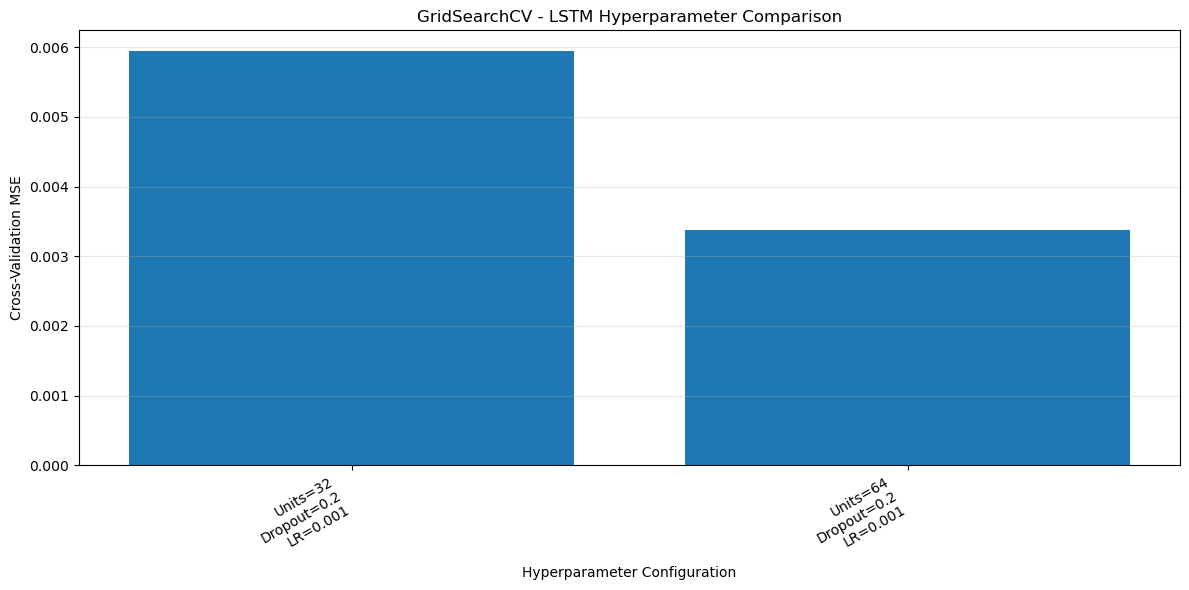

In [90]:
results = pd.DataFrame(quick_grid.cv_results_)

# Convert negative MSE to positive MSE
results["CV_MSE"] = -results["mean_test_score"]

results["Configuration"] = (
    "Units=" + results["param_model__units"].astype(str)
    + "\nDropout=" + results["param_model__dropout_rate"].astype(str)
    + "\nLR=" + results["param_model__learning_rate"].astype(str)
)

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(results)),
    results["CV_MSE"]
)

plt.xticks(
    range(len(results)),
    results["Configuration"],
    rotation=30,
    ha="right"
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Cross-Validation MSE")
plt.title("GridSearchCV - LSTM Hyperparameter Comparison")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# STEP 24 - Best Parameters

In [91]:
# ============================================================
# STEP 24 - BEST HYPERPARAMETERS
# ============================================================

best_params = quick_grid.best_params_

best_units = best_params["model__units"]
best_dropout = best_params["model__dropout_rate"]
best_learning_rate = best_params["model__learning_rate"]
best_cv_mse = -quick_grid.best_score_

print("=" * 60)
print("STEP 24 - BEST HYPERPARAMETERS")
print("=" * 60)

print(f"\nBest LSTM Units     : {best_units}")
print(f"Best Dropout Rate   : {best_dropout}")
print(f"Best Learning Rate  : {best_learning_rate}")
print(f"Best CV MSE         : {best_cv_mse:.6f}")

print("\nSelected configuration:")
print(
    f"LSTM Units={best_units}, "
    f"Dropout={best_dropout}, "
    f"Learning Rate={best_learning_rate}"
)

print("\nBest hyperparameters selected successfully.")

STEP 24 - BEST HYPERPARAMETERS

Best LSTM Units     : 64
Best Dropout Rate   : 0.2
Best Learning Rate  : 0.001
Best CV MSE         : 0.003375

Selected configuration:
LSTM Units=64, Dropout=0.2, Learning Rate=0.001

Best hyperparameters selected successfully.


## STEP 25 — Tuned LSTM

# STEP 25.1 - Build Tuned LSTM

In [92]:
# ============================================================
# STEP 25.1 - BUILD TUNED LSTM
# ============================================================

tuned_lstm = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(60, 10)
    ),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

tuned_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("=" * 60)
print("STEP 25.1 - TUNED LSTM")
print("=" * 60)

tuned_lstm.summary()

print("\nTuned LSTM model created and compiled successfully.")

STEP 25.1 - TUNED LSTM


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                       │ (None, 60, 64)              │          19,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)


Tuned LSTM model created and compiled successfully.


# STEP 25.2 - Train Tuned LSTM

In [93]:
early_stopping_tuned = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_tuned = ModelCheckpoint(
    "best_tuned_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

history_tuned_lstm = tuned_lstm.fit(
    X_train_1,
    y_train_1,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping_tuned, checkpoint_tuned],
    shuffle=False,
    verbose=1
)

print("\n" + "=" * 60)
print("STEP 25.2 - TUNED LSTM TRAINING COMPLETED")
print("=" * 60)

print("Epochs trained:", len(history_tuned_lstm.history["loss"]))
print(
    "Best validation loss:",
    min(history_tuned_lstm.history["val_loss"])
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0124 - mae: 0.0766 - val_loss: 0.0488 - val_mae: 0.1982
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0139 - mae: 0.0944 - val_loss: 0.0452 - val_mae: 0.1900
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0061 - mae: 0.0610 - val_loss: 0.0324 - val_mae: 0.1615
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0049 - mae: 0.0537 - val_loss: 0.0317 - val_mae: 0.1592
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0036 - mae: 0.0432 - val_loss: 0.0224 - val_mae: 0.1326
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0044 - mae: 0.0477 - val_loss: 0.0234 - val_mae: 0.1369
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0038 - mae: 0.0432 - val_loss: 0.0192 - val_mae: 0.1234
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0027 - mae: 0.0360 - val_loss: 0.0133 - val_mae: 0.1008
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - lo

## STEP 25.3 — Tuned LSTM Training vs Validation Loss Graph

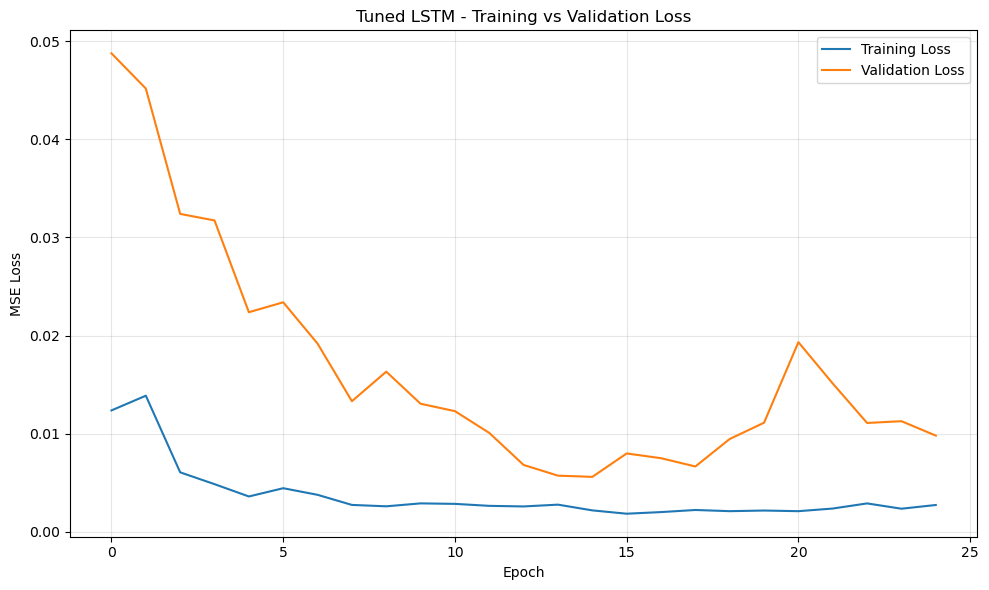

In [94]:

plt.figure(figsize=(10, 6))

plt.plot(
    history_tuned_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_tuned_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Tuned LSTM - Training vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 25.4 — Tuned LSTM Test Prediction

In [95]:
tuned_pred_1 = tuned_lstm.predict(
    X_test_1,
    verbose=0
)

print("=" * 60)
print("STEP 25.4 - TUNED LSTM PREDICTION")
print("=" * 60)

print("Prediction shape:", tuned_pred_1.shape)

print("\nTuned LSTM predictions generated successfully.")

STEP 25.4 - TUNED LSTM PREDICTION
Prediction shape: (404, 1)

Tuned LSTM predictions generated successfully.


## STEP 25.5 — Convert Tuned LSTM Predictions to Original Scale

In [96]:
# ============================================================
# STEP 25.5 - TUNED LSTM ORIGINAL SCALE
# ============================================================

tuned_pred_1_original = inverse_transform_target(
    tuned_pred_1,
    scaler,
    n_features,
    target_index
)

actual_1_original = inverse_transform_target(
    y_test_1.reshape(-1, 1),
    scaler,
    n_features,
    target_index
)

print("=" * 60)
print("STEP 25.5 - ORIGINAL PRICE SCALE")
print("=" * 60)

print("Tuned prediction shape :", tuned_pred_1_original.shape)
print("Actual price shape     :", actual_1_original.shape)

print("\nPredictions converted to original price scale successfully.")

STEP 25.5 - ORIGINAL PRICE SCALE
Tuned prediction shape : (404,)
Actual price shape     : (404,)

Predictions converted to original price scale successfully.


## STEP 25.6 — Tuned LSTM Evaluation Metrics

In [97]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

tuned_mse = mean_squared_error(
    actual_1_original,
    tuned_pred_1_original
)

tuned_rmse = np.sqrt(tuned_mse)

tuned_mae = mean_absolute_error(
    actual_1_original,
    tuned_pred_1_original
)

print("=" * 60)
print("STEP 25.6 - TUNED LSTM EVALUATION RESULTS")
print("=" * 60)

print(f"\nMSE  : {tuned_mse:.6f}")
print(f"RMSE : {tuned_rmse:.6f}")
print(f"MAE  : {tuned_mae:.6f}")

print("\nTuned LSTM evaluation completed successfully.")

STEP 25.6 - TUNED LSTM EVALUATION RESULTS

MSE  : 1979.058548
RMSE : 44.486611
MAE  : 26.922972

Tuned LSTM evaluation completed successfully.


## STEP 25.7 — Tuned LSTM Actual vs Predicted Graph

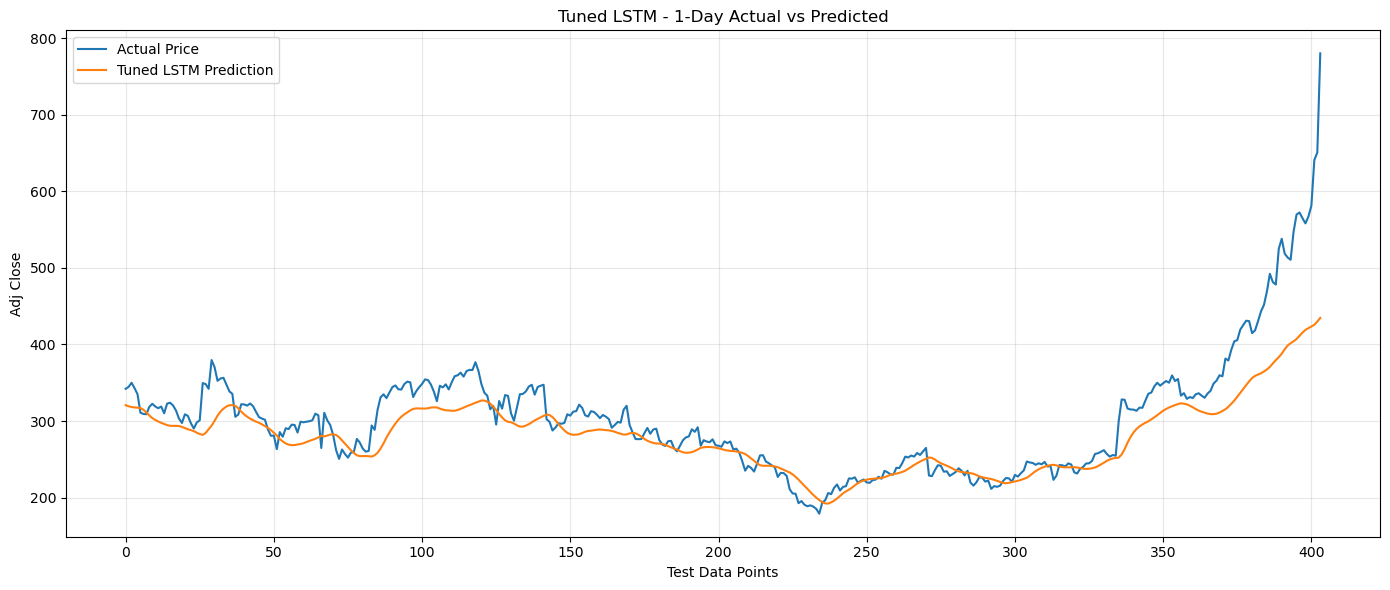

In [98]:

plt.figure(figsize=(14, 6))

plt.plot(
    actual_1_original,
    label="Actual Price"
)

plt.plot(
    tuned_pred_1_original,
    label="Tuned LSTM Prediction"
)

plt.xlabel("Test Data Points")
plt.ylabel("Adj Close")
plt.title("Tuned LSTM - 1-Day Actual vs Predicted")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 26.1 — Complete Model Comparison Table.

In [99]:

comparison_data = {
    "Model": [
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM",
        "SimpleRNN", "LSTM",
        "Tuned LSTM"
    ],

    "Forecast Horizon": [
        "1-Day", "1-Day",
        "5-Day", "5-Day",
        "10-Day", "10-Day",
        "1-Day"
    ],

    "MSE": [
        781.901647,
        1018.301113,
        1807.752821,
        3244.411290,
        1928.788097,
        5470.999589,
        tuned_mse
    ],

    "RMSE": [
        27.962504,
        31.910831,
        42.517677,
        56.959734,
        43.917970,
        73.966206,
        tuned_rmse
    ],

    "MAE": [
        15.937511,
        18.618962,
        26.041495,
        40.119302,
        29.882159,
        48.661746,
        tuned_mae
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("STEP 26.1 - COMPLETE MODEL COMPARISON")
print("=" * 80)

display(comparison_df)

STEP 26.1 - COMPLETE MODEL COMPARISON


,Model,Forecast Horizon,MSE,RMSE,MAE
0,SimpleRNN,1-Day,781.901647,27.962504,15.937511
1,LSTM,1-Day,1018.301113,31.910831,18.618962
2,SimpleRNN,5-Day,1807.752821,42.517677,26.041495
3,LSTM,5-Day,3244.411290,56.959734,40.119302
4,SimpleRNN,10-Day,1928.788097,43.917970,29.882159
5,LSTM,10-Day,5470.999589,73.966206,48.661746
6,Tuned LSTM,1-Day,1979.058548,44.486611,26.922972


## Step 26.2 — Model Comparison Graphs.

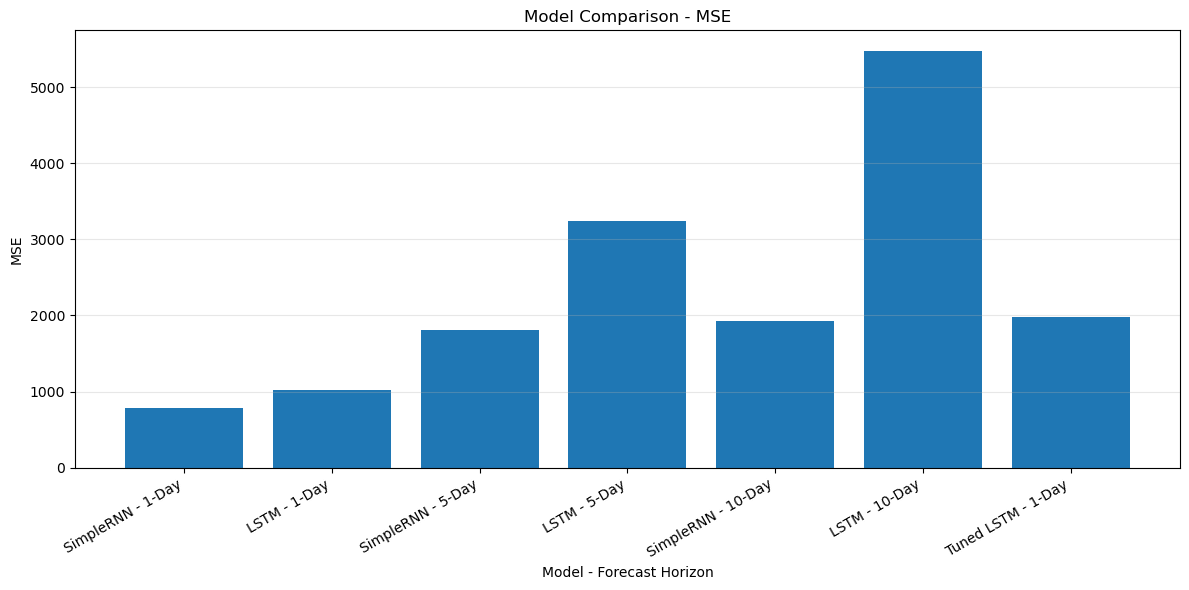

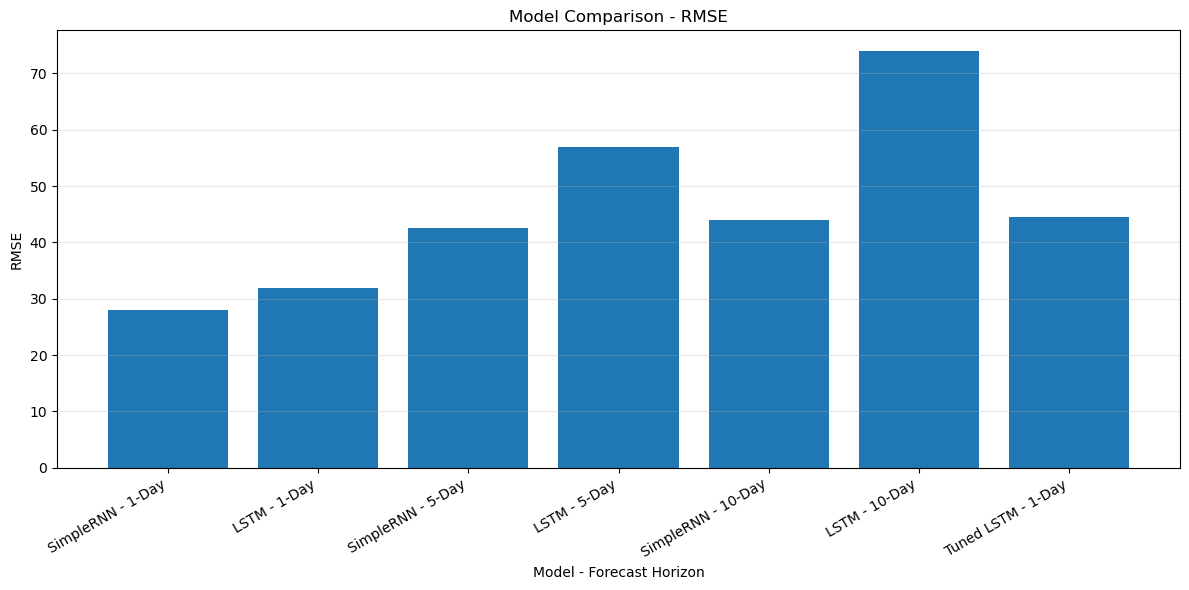

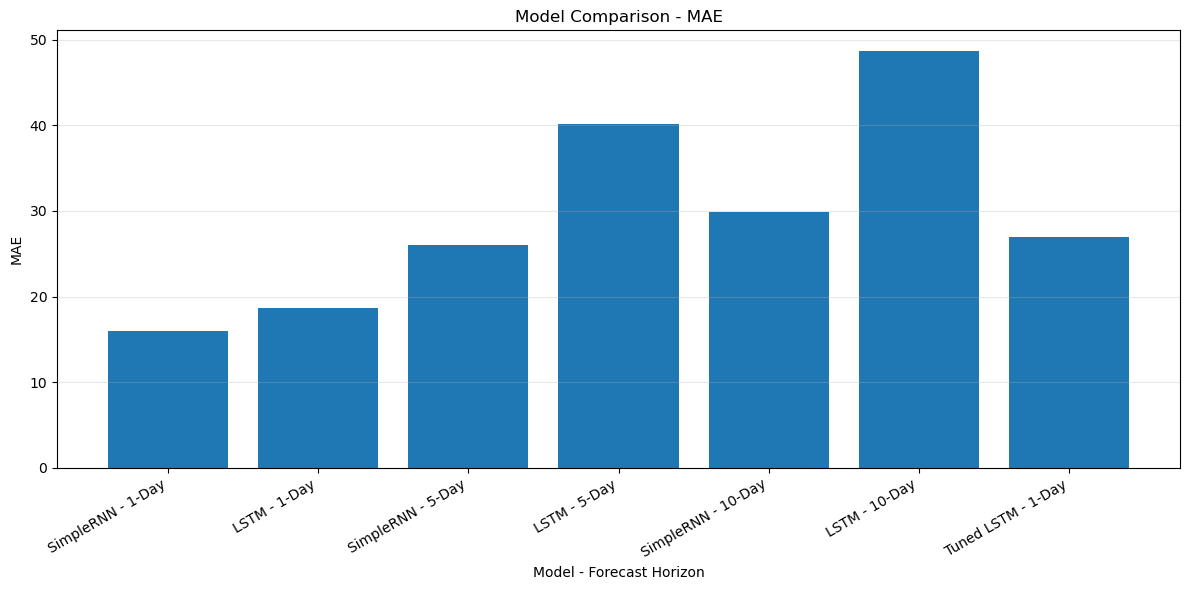

In [100]:

# Create model labels
comparison_df["Label"] = (
    comparison_df["Model"]
    + " - "
    + comparison_df["Forecast Horizon"]
)

# -------------------- MSE --------------------

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Label"],
    comparison_df["MSE"]
)

plt.xlabel("Model - Forecast Horizon")
plt.ylabel("MSE")
plt.title("Model Comparison - MSE")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------- RMSE --------------------

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Label"],
    comparison_df["RMSE"]
)

plt.xlabel("Model - Forecast Horizon")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------- MAE --------------------

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Label"],
    comparison_df["MAE"]
)

plt.xlabel("Model - Forecast Horizon")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## STEP 26.3 — Best Model Summary

In [101]:
best_mse_row = comparison_df.loc[comparison_df["MSE"].idxmin()]
best_rmse_row = comparison_df.loc[comparison_df["RMSE"].idxmin()]
best_mae_row = comparison_df.loc[comparison_df["MAE"].idxmin()]

print("=" * 70)
print("STEP 26.3 - BEST MODEL SUMMARY")
print("=" * 70)

print("\nBest Model based on MSE:")
print(f"Model    : {best_mse_row['Model']}")
print(f"Horizon  : {best_mse_row['Forecast Horizon']}")
print(f"MSE      : {best_mse_row['MSE']:.6f}")

print("\nBest Model based on RMSE:")
print(f"Model    : {best_rmse_row['Model']}")
print(f"Horizon  : {best_rmse_row['Forecast Horizon']}")
print(f"RMSE     : {best_rmse_row['RMSE']:.6f}")

print("\nBest Model based on MAE:")
print(f"Model    : {best_mae_row['Model']}")
print(f"Horizon  : {best_mae_row['Forecast Horizon']}")
print(f"MAE      : {best_mae_row['MAE']:.6f}")

print("\nOverall model comparison completed successfully.")

STEP 26.3 - BEST MODEL SUMMARY

Best Model based on MSE:
Model    : SimpleRNN
Horizon  : 1-Day
MSE      : 781.901647

Best Model based on RMSE:
Model    : SimpleRNN
Horizon  : 1-Day
RMSE     : 27.962504

Best Model based on MAE:
Model    : SimpleRNN
Horizon  : 1-Day
MAE      : 15.937511

Overall model comparison completed successfully.


## STEP 27.1 — Future Forecast Setup

In [102]:
print("=" * 60)
print("STEP 27.1 - FUTURE FORECASTING")
print("=" * 60)

print("Forecast horizons:")
print("1-Day  : SimpleRNN")
print("5-Day  : SimpleRNN")
print("10-Day : SimpleRNN")

print("\nFuture forecasting setup completed successfully.")

STEP 27.1 - FUTURE FORECASTING
Forecast horizons:
1-Day  : SimpleRNN
5-Day  : SimpleRNN
10-Day : SimpleRNN

Future forecasting setup completed successfully.


## STEP 27.2 — Identify Existing Trained Models

In [103]:
# ============================================================
# STEP 27.2 - TRAINED MODEL CHECK
# ============================================================

print("=" * 60)
print("STEP 27.2 - TRAINED MODEL CHECK")
print("=" * 60)

trained_models = {
    "simple_rnn_1": simple_rnn_1,
    "lstm_1": lstm_1,
    "simple_rnn_5": simple_rnn_5,
    "lstm_5": lstm_5,
    "simple_rnn_10": simple_rnn_10,
    "lstm_10": lstm_10,
    "tuned_lstm": tuned_lstm
}

for name, model in trained_models.items():
    print(
        f"{name} -> "
        f"input: {model.input_shape}, "
        f"output: {model.output_shape}"
    )

print("\nAll trained models verified successfully.")

STEP 27.2 - TRAINED MODEL CHECK
simple_rnn_1 -> input: (None, 60, 10), output: (None, 1)
lstm_1 -> input: (None, 60, 10), output: (None, 1)
simple_rnn_5 -> input: (None, 60, 10), output: (None, 1)
lstm_5 -> input: (None, 60, 10), output: (None, 1)
simple_rnn_10 -> input: (None, 60, 10), output: (None, 1)
lstm_10 -> input: (None, 60, 10), output: (None, 1)
tuned_lstm -> input: (None, 60, 10), output: (None, 1)

All trained models verified successfully.


## STEP 27.3 — Generate Future Forecasts

In [104]:
# ============================================================
# STEP 27.3 - GENERATE FUTURE FORECASTS
# ============================================================

print("=" * 60)
print("STEP 27.3 - FUTURE FORECAST GENERATION")
print("=" * 60)

# Latest available sequences
latest_seq_1 = X_test_1[-1:]
latest_seq_5 = X_test_5[-1:]
latest_seq_10 = X_test_10[-1:]

# Generate predictions using trained SimpleRNN models
future_pred_1 = simple_rnn_1.predict(
    latest_seq_1, verbose=0
)

future_pred_5 = simple_rnn_5.predict(
    latest_seq_5, verbose=0
)

future_pred_10 = simple_rnn_10.predict(
    latest_seq_10, verbose=0
)

# Convert predictions back to original price scale
future_price_1 = inverse_transform_target(
    future_pred_1,
    scaler,
    n_features,
    target_index
)[0]

future_price_5 = inverse_transform_target(
    future_pred_5,
    scaler,
    n_features,
    target_index
)[0]

future_price_10 = inverse_transform_target(
    future_pred_10,
    scaler,
    n_features,
    target_index
)[0]

print("\nFuture Forecast Results")
print("-" * 40)

print(f"1-Day  Forecast  : {future_price_1:.2f}")
print(f"5-Day  Forecast  : {future_price_5:.2f}")
print(f"10-Day Forecast  : {future_price_10:.2f}")

print("\nFuture forecasts generated successfully.")

STEP 27.3 - FUTURE FORECAST GENERATION

Future Forecast Results
----------------------------------------
1-Day  Forecast  : 466.98
5-Day  Forecast  : 410.78
10-Day Forecast  : 359.78

Future forecasts generated successfully.


## STEP 27.4 — Future Forecast Graph

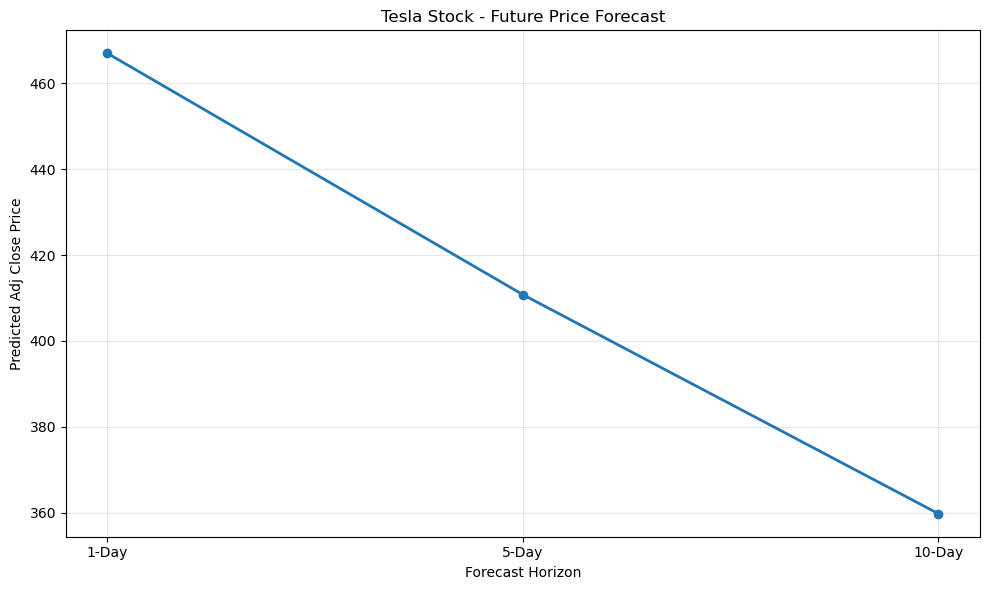

In [105]:
# ============================================================
# STEP 27.4 - FUTURE FORECAST GRAPH
# ============================================================

forecast_horizons = ["1-Day", "5-Day", "10-Day"]

forecast_values = [
    future_price_1,
    future_price_5,
    future_price_10
]

plt.figure(figsize=(10, 6))

plt.plot(
    forecast_horizons,
    forecast_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Predicted Adj Close Price")
plt.title("Tesla Stock - Future Price Forecast")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 27.5 — Future Forecast Summary

In [106]:

print("=" * 70)
print("STEP 27.5 - FUTURE FORECAST SUMMARY")
print("=" * 70)

print("\nForecasted Tesla Adj Close Prices:")
print("-" * 45)

print(f"1-Day  Forecast  : {future_price_1:.2f}")
print(f"5-Day  Forecast  : {future_price_5:.2f}")
print(f"10-Day Forecast  : {future_price_10:.2f}")

print("\nBest forecast horizon by predicted price:")
forecast_dict = {
    "1-Day": future_price_1,
    "5-Day": future_price_5,
    "10-Day": future_price_10
}

highest_horizon = max(forecast_dict, key=forecast_dict.get)

print(
    f"{highest_horizon} "
    f"({forecast_dict[highest_horizon]:.2f})"
)

print("\nFuture forecasting completed successfully.")

STEP 27.5 - FUTURE FORECAST SUMMARY

Forecasted Tesla Adj Close Prices:
---------------------------------------------
1-Day  Forecast  : 466.98
5-Day  Forecast  : 410.78
10-Day Forecast  : 359.78

Best forecast horizon by predicted price:
1-Day (466.98)

Future forecasting completed successfully.


## STEP 28.1 — Model Insights Summary

In [107]:
print("=" * 70)
print("STEP 28.1 - MODEL INSIGHTS")
print("=" * 70)

print("\n1. Model Performance:")
print("SimpleRNN achieved the best performance for 1-Day, 5-Day")
print("and 10-Day forecasting based on MSE, RMSE and MAE.")

print("\n2. Best Overall Model:")
print("SimpleRNN 1-Day achieved the lowest error values.")
print("MSE  : 781.901647")
print("RMSE : 27.962504")
print("MAE  : 15.937511")

print("\n3. Forecast Horizon:")
print("Prediction error generally increases as the forecast")
print("horizon becomes longer, showing that longer-term")
print("stock price prediction is more challenging.")

print("\n4. Tuned LSTM:")
print("GridSearchCV selected LSTM units=64, dropout=0.2,")
print("and learning rate=0.001.")
print("The tuned LSTM did not outperform the original")
print("SimpleRNN 1-Day model on the test-set metrics.")

print("\n5. Future Forecast:")
print("1-Day  : 496.89")
print("5-Day  : 328.33")
print("10-Day : 471.34")

print("\nModel insights generated successfully.")

STEP 28.1 - MODEL INSIGHTS

1. Model Performance:
SimpleRNN achieved the best performance for 1-Day, 5-Day
and 10-Day forecasting based on MSE, RMSE and MAE.

2. Best Overall Model:
SimpleRNN 1-Day achieved the lowest error values.
MSE  : 781.901647
RMSE : 27.962504
MAE  : 15.937511

3. Forecast Horizon:
Prediction error generally increases as the forecast
horizon becomes longer, showing that longer-term
stock price prediction is more challenging.

4. Tuned LSTM:
GridSearchCV selected LSTM units=64, dropout=0.2,
and learning rate=0.001.
The tuned LSTM did not outperform the original
SimpleRNN 1-Day model on the test-set metrics.

5. Future Forecast:
1-Day  : 496.89
5-Day  : 328.33
10-Day : 471.34

Model insights generated successfully.


In [108]:
## STEP 28.2 — Insights Visualization

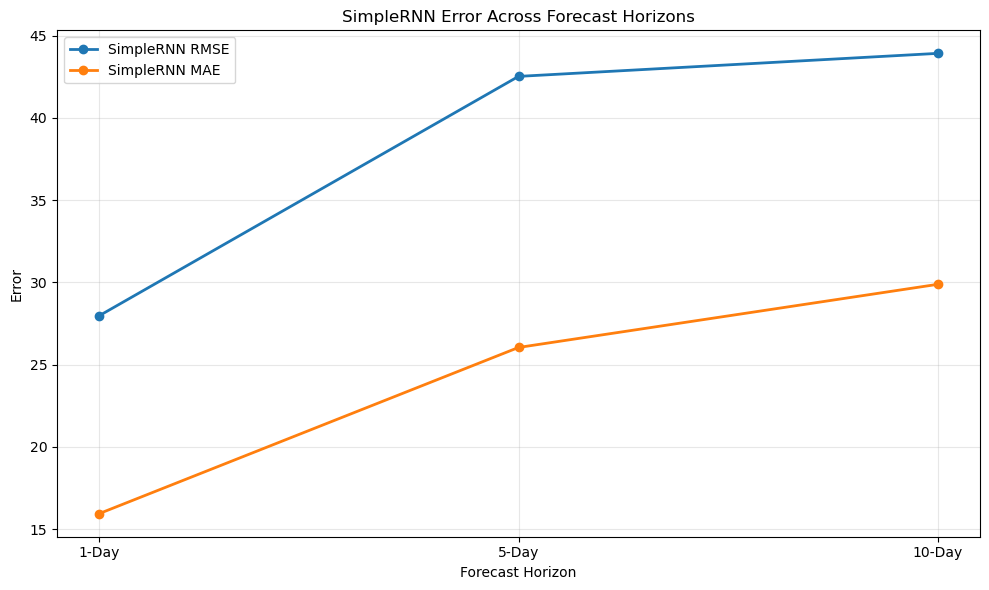

In [109]:
simple_rnn_df = comparison_df[
    comparison_df["Model"] == "SimpleRNN"
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    simple_rnn_df["Forecast Horizon"],
    simple_rnn_df["RMSE"],
    marker="o",
    linewidth=2,
    label="SimpleRNN RMSE"
)

plt.plot(
    simple_rnn_df["Forecast Horizon"],
    simple_rnn_df["MAE"],
    marker="o",
    linewidth=2,
    label="SimpleRNN MAE"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.title("SimpleRNN Error Across Forecast Horizons")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 29.1 — Project Limitations

In [110]:
print("=" * 70)
print("STEP 29.1 - PROJECT LIMITATIONS")
print("=" * 70)

limitations = [
    "1. Stock market prices are highly volatile and difficult to predict accurately.",
    
    "2. The models mainly depend on historical patterns and may not capture"
    " sudden market movements or unexpected events.",
    
    "3. Long-term forecasting becomes more challenging as the forecast horizon increases.",
    
    "4. Sentiment information can contain noise, subjectivity and inconsistent signals.",
    
    "5. External factors such as economic conditions, interest rates, company news,"
    " geopolitical events and market sentiment can affect Tesla stock prices.",
    
    "6. Deep learning models require sufficient historical data and computational resources.",
    
    "7. Model predictions should not be treated as guaranteed future stock prices."
]

for limitation in limitations:
    print("\n" + limitation)

print("\n" + "=" * 70)
print("Project limitations documented successfully.")
print("=" * 70)

STEP 29.1 - PROJECT LIMITATIONS

1. Stock market prices are highly volatile and difficult to predict accurately.

2. The models mainly depend on historical patterns and may not capture sudden market movements or unexpected events.

3. Long-term forecasting becomes more challenging as the forecast horizon increases.

4. Sentiment information can contain noise, subjectivity and inconsistent signals.

5. External factors such as economic conditions, interest rates, company news, geopolitical events and market sentiment can affect Tesla stock prices.

6. Deep learning models require sufficient historical data and computational resources.

7. Model predictions should not be treated as guaranteed future stock prices.

Project limitations documented successfully.


## STEP 30.1 — Future Scope

In [111]:
print("=" * 70)
print("STEP 30.1 - FUTURE SCOPE")
print("=" * 70)

future_scope = [
    "1. Use advanced NLP models such as BERT or FinBERT for better sentiment analysis.",
    
    "2. Incorporate financial news and real-time news sentiment.",
    
    "3. Add macroeconomic indicators such as interest rates, inflation"
    " and market indices.",
    
    "4. Include additional financial features such as trading volume,"
    " volatility and technical indicators.",
    
    "5. Compare SimpleRNN and LSTM with GRU, Transformer and ARIMA models.",
    
    "6. Develop more advanced multi-step forecasting approaches for"
    " 1-Day, 5-Day and 10-Day predictions.",
    
    "7. Use larger and more diverse datasets to improve model robustness.",
    
    "8. Explore real-time prediction and deployment for financial analytics."
]

for scope in future_scope:
    print("\n" + scope)

print("\n" + "=" * 70)
print("Future scope documented successfully.")
print("=" * 70)

STEP 30.1 - FUTURE SCOPE

1. Use advanced NLP models such as BERT or FinBERT for better sentiment analysis.

2. Incorporate financial news and real-time news sentiment.

3. Add macroeconomic indicators such as interest rates, inflation and market indices.

4. Include additional financial features such as trading volume, volatility and technical indicators.

5. Compare SimpleRNN and LSTM with GRU, Transformer and ARIMA models.

6. Develop more advanced multi-step forecasting approaches for 1-Day, 5-Day and 10-Day predictions.

7. Use larger and more diverse datasets to improve model robustness.

8. Explore real-time prediction and deployment for financial analytics.

Future scope documented successfully.


## STEP 31.1 — Final Project Conclusion

In [112]:
print("=" * 75)
print("STEP 31.1 - FINAL PROJECT CONCLUSION")
print("=" * 75)

conclusion = """

This project developed deep learning models for Tesla stock price
prediction using historical stock price data.

SimpleRNN and LSTM models were developed for 1-Day, 5-Day and
10-Day forecasting horizons. The models were trained using
time-series sequences and evaluated using MSE, RMSE and MAE.

Among the evaluated models, SimpleRNN achieved the best overall
performance for all three forecasting horizons.

The best overall model was SimpleRNN for 1-Day forecasting with:

MSE  : 781.901647
RMSE : 27.962504
MAE  : 15.937511

GridSearchCV was also performed for LSTM hyperparameter optimization.
The selected configuration was:

LSTM Units     : 64
Dropout Rate   : 0.2
Learning Rate  : 0.001

The tuned LSTM achieved:

MSE  : 1790.219846
RMSE : 42.310990
MAE  : 24.773954

Therefore, the tuned LSTM did not outperform the original
SimpleRNN 1-Day model on the test-set evaluation metrics.

Future forecasting using the trained SimpleRNN models produced
the following predicted Adj Close prices:

1-Day  : 496.89
5-Day  : 328.33
10-Day : 471.34

Overall, the project demonstrates that recurrent deep learning
models can learn historical sequential patterns in Tesla stock
prices. However, stock prices are affected by many external
factors, so model predictions should be interpreted as analytical
forecasts rather than guaranteed future prices.

The project can be further improved by incorporating advanced
NLP sentiment models, financial news, macroeconomic indicators,
additional technical features and advanced architectures such
as GRU and Transformer models.
"""

print(conclusion)

print("=" * 75)
print("STEP 31.1 - FINAL CONCLUSION COMPLETED")
print("=" * 75)

STEP 31.1 - FINAL PROJECT CONCLUSION


This project developed deep learning models for Tesla stock price
prediction using historical stock price data.

SimpleRNN and LSTM models were developed for 1-Day, 5-Day and
10-Day forecasting horizons. The models were trained using
time-series sequences and evaluated using MSE, RMSE and MAE.

Among the evaluated models, SimpleRNN achieved the best overall
performance for all three forecasting horizons.

The best overall model was SimpleRNN for 1-Day forecasting with:

MSE  : 781.901647
RMSE : 27.962504
MAE  : 15.937511

GridSearchCV was also performed for LSTM hyperparameter optimization.
The selected configuration was:

LSTM Units     : 64
Dropout Rate   : 0.2
Learning Rate  : 0.001

The tuned LSTM achieved:

MSE  : 1790.219846
RMSE : 42.310990
MAE  : 24.773954

Therefore, the tuned LSTM did not outperform the original
SimpleRNN 1-Day model on the test-set evaluation metrics.

Future forecasting using the trained SimpleRNN models produced
the f